In [1]:
import sys
from pathlib import Path

repo_root = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN')
sys.path.insert(0, str(repo_root))


### 1. Configuração do Ambiente

In [ ]:
#!pip install "cognite-sdk[pandas]" matplotlib seaborn tensorflow plotly -q

import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.stattools import acf
from industrial_ts.dataloader import DataLoader
import json
from getpass import getpass
#import tensorflow as tf
#from tensorflow import keras

print("Bibliotecas importadas com sucesso!")






Updated: UnsupervisedStateSegmenter now supports multi-channel (multivariate) series.

Bibliotecas importadas com sucesso!


/home/ferna/fe/lib/python3.12/site-packages/ipykernel/ipkernel.py:772: UserWarning: You are using version='7.83.1' of the SDK, however version='7.92.0' is available. To suppress this warning, either upgrade or do the following:
>>> from cognite.client.config import global_config
>>> global_config.disable_pypi_version_check = True
  _threading_Thread_run(self)


In [3]:
import debugpy
debugpy.listen(('0.0.0.0', 5678))






('0.0.0.0', 5678)

In [ ]:
import debugpy
debugpy.listen(("0.0.0.0", 5678))
print("aguardando debugger...")
debugpy.wait_for_client()
print("conectado!")


In [4]:
os.environ['COGNITE_CLIENT_SECRET'] = getpass("Enter COGNITE_CLIENT")






### 2. Ativar o DataLoader

In [5]:
import importlib
import sys
importlib.reload(sys.modules['industrial_ts.dataloader'])
from industrial_ts.dataloader import DataLoader
dl = DataLoader()
dl.add_segments(segments=3, window=10, step=10, series=[
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActShaft Power',
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActPress Ratio'  
], path="segmenter_model_10.pkl"
)
#dl.segmenter.save("segmenter_model_10.pkl")








Buscando dados para as 12 séries temporais encontradas.


### 10 Pós-processamento

In [6]:
for i in [2]:
    dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2







/tmp/ipykernel_4825/4230046523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2


In [7]:
dl.add_time_to_change_state_timestamp()






# TSDF GRU 11*32

In [13]:
from pathlib import Path
from industrial_ts.gru import TSDF_GRU



In [14]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength

from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_gru_H{h}_{clamp}_{opt}")
# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=11*32,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stage ActCompr Poly Eff',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=500,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            max_drop=MAX_DROP,  # ablation for masking strength
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_GRU_final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
    x_min=run_config_gru['train_params'].get('x_min'),
    x_max=run_config_gru['train_params'].get('x_max'),
    clamp_in_forward=CLAMP_FORWARD,
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    max_drop=run_config_gru['train_params'].get('max_drop', MAX_DROP),
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"TSDF_GRU_{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)


# --- Clamp only at inference/plot (no grad) ---
def clamp_output(x_hat, x_min=None, x_max=None):
    if x_min is not None:
        x_hat = x_hat.clamp(min=x_min)
    if x_max is not None:
        x_hat = x_hat.clamp(max=x_max)
    return x_hat



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_GRU', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.761836 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.765720 ± 0.315765 | Val micro:0.513090 ± 0.009136 
          >> Test macro:0.757826 ± 0.310880 | micro:0.508948 ± 0.008512
Epoch 2/500 | Train(sampled) L1:0.762233 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.755072 ± 0.309196 | Val micro:0.507698 ± 0.009058 
          >> Test macro:0.748592 ± 0.306033 | micro:0.503594 ± 0.008433
Epoch 3/500 | Train(sampled) L1:0.743896 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.738780 ± 0.299801 | Val micro:0.498922 ± 0.008929 
          >> T

# TSDF_GRU com hidden=24

In [8]:
from pathlib import Path
from industrial_ts.gru import TSDF_GRU



In [9]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength

from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_gru_H{h}_{clamp}_{opt}")
# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=24,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stage ActCompr Poly Eff',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=500,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            max_drop=MAX_DROP,  # ablation for masking strength
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_GRU_final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
    x_min=run_config_gru['train_params'].get('x_min'),
    x_max=run_config_gru['train_params'].get('x_max'),
    clamp_in_forward=CLAMP_FORWARD,
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    max_drop=run_config_gru['train_params'].get('max_drop', MAX_DROP),
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"TSDF_GRU_{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)


# --- Clamp only at inference/plot (no grad) ---
def clamp_output(x_hat, x_min=None, x_max=None):
    if x_min is not None:
        x_hat = x_hat.clamp(min=x_min)
    if x_max is not None:
        x_hat = x_hat.clamp(max=x_max)
    return x_hat



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_GRU', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.764295 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.766280 ± 0.311151 | Val micro:0.517341 ± 0.009220 
          >> Test macro:0.756324 ± 0.304768 | micro:0.512339 ± 0.008539
Epoch 2/500 | Train(sampled) L1:0.762955 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.756841 ± 0.309852 | Val micro:0.508941 ± 0.009167 
          >> Test macro:0.747289 ± 0.304100 | micro:0.503839 ± 0.008493
Epoch 3/500 | Train(sampled) L1:0.734863 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.744781 ± 0.308248 | Val micro:0.498164 ± 0.009085 
          >> T

# TSDF GRU hidden 8

In [10]:
from pathlib import Path
from industrial_ts.gru import TSDF_GRU



In [11]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength

from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_gru_H{h}_{clamp}_{opt}")
# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=8,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stage ActCompr Poly Eff',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=500,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            max_drop=MAX_DROP,  # ablation for masking strength
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_GRU_final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
    x_min=run_config_gru['train_params'].get('x_min'),
    x_max=run_config_gru['train_params'].get('x_max'),
    clamp_in_forward=CLAMP_FORWARD,
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    max_drop=run_config_gru['train_params'].get('max_drop', MAX_DROP),
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"TSDF_GRU_{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)


# --- Clamp only at inference/plot (no grad) ---
def clamp_output(x_hat, x_min=None, x_max=None):
    if x_min is not None:
        x_hat = x_hat.clamp(min=x_min)
    if x_max is not None:
        x_hat = x_hat.clamp(max=x_max)
    return x_hat



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RUN CONFIG: {'model': 'TSDF_GRU', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.828821 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.837979 ± 0.349061 | Val micro:0.558709 ± 0.009397 
          >> Test macro:0.826785 ± 0.339217 | micro:0.555221 ± 0.008828
Epoch 2/500 | Train(sampled) L1:0.812473 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.815676 ± 0.342951 | Val micro:0.541295 ± 0.009321 
          >> Test macro:0.804916 ± 0.333976 | micro:0.537548 ± 0.008738
Epoch 3/500 | Train(sampled) L1:0.801678 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.788559 ± 0.333652 | Val micro:0.521618 ± 0.009208 
          >> T

# TSDF seqKANSeq hidden 8 - kh None

In [15]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)


<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [16]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': None,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=8,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [17]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 8, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.861903 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.841660 ± 0.345475 | Val micro:0.565260 ± 0.009446 
          >> Test macro:0.835931 ± 0.337494 | micro:0.565746 ± 0.008997
Epoch 2/500 | Train(sampled) L1:0.829155 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.818017 ± 0.332818 | Val micro:0.551743 ± 0.009258 
          >> Test macro:0.812530 ± 0.326050 | micro:0.551508 ± 0.008766
Epoch 3/500 | Train(sampled) L1:0.801337 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.798732 ± 0.323635 | Val micro:0.539806 ± 0.009136 
          >> T

# TSDF seqKANSeq hidden 8 - kh 4

In [8]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [14]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',  # não mexer.
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': 4,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=8,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [15]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 8, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.761946 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.775338 ± 0.331481 | Val micro:0.510134 ± 0.009268 
          >> Test macro:0.765087 ± 0.323326 | micro:0.506245 ± 0.008649
Epoch 2/500 | Train(sampled) L1:0.765905 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.770061 ± 0.326023 | Val micro:0.509224 ± 0.009276 
          >> Test macro:0.759395 ± 0.318131 | micro:0.504713 ± 0.008626
Epoch 3/500 | Train(sampled) L1:0.756118 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.766484 ± 0.319459 | Val micro:0.510898 ± 0.009277 
          >> T

# TSDF seqKANSeq hidden 8 - kh 6

In [16]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [17]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': 6,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=8,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [18]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 8, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.762376 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.775331 ± 0.331437 | Val micro:0.510162 ± 0.009267 
          >> Test macro:0.765105 ± 0.323298 | micro:0.506285 ± 0.008648
Epoch 2/500 | Train(sampled) L1:0.764754 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.770118 ± 0.326065 | Val micro:0.509247 ± 0.009278 
          >> Test macro:0.759430 ± 0.318157 | micro:0.504727 ± 0.008627
Epoch 3/500 | Train(sampled) L1:0.764319 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.765785 ± 0.318530 | Val micro:0.510942 ± 0.009253 
          >> T

# TSDF seqKANSeq hidden 24 - kh 12

In [22]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [23]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': 12,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=24,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [24]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.758015 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.765826 ± 0.319674 | Val micro:0.510068 ± 0.009240 
          >> Test macro:0.755226 ± 0.312532 | micro:0.505025 ± 0.008581
Epoch 2/500 | Train(sampled) L1:0.751454 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.762714 ± 0.307732 | Val micro:0.516510 ± 0.009207 
          >> Test macro:0.752749 ± 0.301885 | micro:0.511072 ± 0.008531
Epoch 3/500 | Train(sampled) L1:0.762918 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.763411 ± 0.310600 | Val micro:0.514913 ± 0.009240 
          >> T

# TSDF seqKANSeq hidden 24 - kh none

In [8]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [10]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3), 'sparse_init': False,
             },
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3), 'sparse_init': False,
               },
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': None,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=24,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [11]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.767400 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.762894 ± 0.312126 | Val micro:0.513176 ± 0.009234 
          >> Test macro:0.752373 ± 0.305702 | micro:0.507640 ± 0.008554
Epoch 2/500 | Train(sampled) L1:0.745927 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.756030 ± 0.308298 | Val micro:0.509374 ± 0.009145 
          >> Test macro:0.746668 ± 0.302918 | micro:0.504164 ± 0.008478
Epoch 3/500 | Train(sampled) L1:0.727770 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.724245 ± 0.298449 | Val micro:0.485468 ± 0.008935 
          >> T

# TSDF seqKANSeq hidden 11*32  kh 176

In [26]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [27]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': 176,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=11*32,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [28]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 352, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.783375 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.755209 ± 0.312027 | Val micro:0.505569 ± 0.009022 
          >> Test macro:0.748384 ± 0.307592 | micro:0.502138 ± 0.008434
Epoch 2/500 | Train(sampled) L1:0.725093 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.553873 ± 0.268312 | Val micro:0.339208 ± 0.007510 
          >> Test macro:0.567599 ± 0.286923 | micro:0.337899 ± 0.007128
Epoch 3/500 | Train(sampled) L1:0.710564 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.553216 ± 0.255542 | Val micro:0.348767 ± 0.007803 
          >> T

# TSDF seqKANSeq hidden 11*32  kh None

In [18]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [19]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': None,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=11*32,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [20]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 352, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.775101 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.707139 ± 0.277621 | Val micro:0.485025 ± 0.008720 
          >> Test macro:0.703651 ± 0.279856 | micro:0.479610 ± 0.008066
Epoch 2/500 | Train(sampled) L1:0.616977 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.488711 ± 0.209487 | Val micro:0.321109 ± 0.006618 
          >> Test macro:0.512657 ± 0.237433 | micro:0.322578 ± 0.006459
Epoch 3/500 | Train(sampled) L1:0.514877 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.411054 ± 0.159933 | Val micro:0.283099 ± 0.005613 
          >> T

# TSDF seqKANSeq grid 20 - H 24 kh None

In [11]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [12]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 20, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 20, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': None,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=24,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=500,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [13]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 24, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/500 | Train(sampled) L1:0.758304 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.770342 ± 0.326813 | Val micro:0.508873 ± 0.009264 
          >> Test macro:0.759592 ± 0.318955 | micro:0.504249 ± 0.008620
Epoch 2/500 | Train(sampled) L1:0.745675 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.763562 ± 0.309630 | Val micro:0.515840 ± 0.009238 
          >> Test macro:0.753170 ± 0.303419 | micro:0.510265 ± 0.008554
Epoch 3/500 | Train(sampled) L1:0.746661 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.736790 ± 0.306286 | Val micro:0.491743 ± 0.009032 
          >> T

# TSDF seqKANSeq grid 8, H 4 , Kh None

In [19]:
import importlib
import industrial_ts.tsdiffusion as tsd
importlib.reload(tsd)

import industrial_ts.seqKAN as sk
importlib.reload(sk)

<module 'industrial_ts.seqKAN' from '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/seqKAN.py'>

In [20]:
CLAMP_FORWARD = True  # ablation: clamp inside forward?
MAX_DROP = 0.3  # ablation: masking strength
USE_KANOUT_REBUILD = True  # x_hat direto do kan_out (sem reconstruct e sem MLP decoder)
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    cell = kp.get('cell', kp.get('hidden', {}))
    grid = cell.get('grid', kp.get('grid', 'g?'))
    grid_eps = cell.get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    h = cfg.get('hidden_dim', 'H?')
    suffix = '_kanout' if globals().get('USE_KANOUT_REBUILD', False) else ''
    kh = None
    try:
        kh = kp.get('topk', {}).get('k_h', None)
    except Exception:
        kh = None
    kh_tag = f"_kh{kh}" if kh is not None else ""
    return _safe(f"tsdf_seqKANseq_H{h}_g{grid}_ge{grid_eps}_{clamp}_{opt}{kh_tag}{suffix}")
# config standalone (nao depende de outras celulas)
grid_eps = globals().get('grid_eps', 0.2)
kan_params_seq = {
    'cell': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': { 'grid_eps': grid_eps, 'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'kind': 'structural',
        'conn_mode': 'per_out',
        'score': 'coef_l2',
        'k_x': None,
        'k_h': None,
        'k_m': None,
        'mask_size': 11,
        'k_out': None,
        'warmup_epochs': 30,
    },
}

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=4,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stage ActCompr Poly Eff',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=1000,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        max_drop=MAX_DROP,  # ablation for masking strength
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"TSDF_seqKANSeq_final_reconstruct_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
    x_min=run_config_tsdf_seqkanseq['train_params'].get('x_min'),
    x_max=run_config_tsdf_seqkanseq['train_params'].get('x_max'),
    noise_on_mask=False,
    clamp_in_forward=CLAMP_FORWARD,
)
import torch
device = torch.device('cuda')
model_tsdf_seqkanseq = model_tsdf_seqkanseq.to(device)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [21]:
train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    max_drop=run_config_tsdf_seqkanseq['train_params'].get('max_drop', MAX_DROP),
    device=device,
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"TSDF_seqKANSeq_{run_name_tsdf_seqkanseq}.pt"
import torch
device = torch.device('cuda')
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


RUN CONFIG: {'model': 'TSDF_seqKANSeq', 'grid': None, 'grid_eps': None, 'in_channels': 11, 'hidden_dim': 4, 'x_min': -3.0, 'x_max': 3.0}


/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:711: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


CLAMP COUNTS train | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 21905/161900 (13.53%) | = 3.0: 0/161900 (0.00%)
CLAMP COUNTS valid | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7228/53970 (13.39%) | = 3.0: 0/53970 (0.00%)
CLAMP COUNTS test | PH (CBM) 1st Stage ExpCompr Poly Eff | = -3.0: 7044/53960 (13.05%) | = 3.0: 0/53960 (0.00%)
Epoch 1/1000 | Train(sampled) L1:0.760729 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.776452 ± 0.333101 | Val micro:0.509952 ± 0.009287 
          >> Test macro:0.765862 ± 0.324706 | micro:0.505915 ± 0.008665
Epoch 2/1000 | Train(sampled) L1:0.763784 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.773071 ± 0.329913 | Val micro:0.509121 ± 0.009276 
          >> Test macro:0.762435 ± 0.321772 | micro:0.504837 ± 0.008642
Epoch 3/1000 | Train(sampled) L1:0.760672 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.769508 ± 0.325667 | Val micro:0.508955 ± 0.009255 
          >

# --- CHECKPOINT_LOADER_V2

In [8]:
# --- CHECKPOINT_LOADER_V2 (nao sobrescreve suas celulas) ---
import torch
from industrial_ts.seqKAN import TSDF_seqKANSeq
from industrial_ts.gru import TSDF_GRU

# 1) Preencha os caminhos abaixo
SEQKAN_CKPT_PATH = r"/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_seqKANSeq_tsdf_seqKANseq_H24_g8_ge0.2_c-3.0_3.0_radam_kh12_kanout_best.pt"
GRU_CKPT_PATH    = r"/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_GRU_final_rebuild_tsdf_gru_H24_c-3.0_3.0_radam_best_champion.pt"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2) Se precisar, ajuste manualmente. Se None, tenta inferir do state_dict.
SEQKAN_CFG = {
    'in_channels': 11,
    'hidden_dim': 24,
    'kan_params': {
        'cell':   {'grid': 8, 'k': 3, 'grid_range': (-3.0, 3.0), 'grid_eps': 0.2},
        'output': {'grid': 8, 'k': 3, 'grid_range': (-3.0, 3.0), 'grid_eps': 0.2},
    },
    'lam': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'x_min': -3.0,
    'x_max': 3.0,
}

GRU_CFG = {
    'in_channels': 11,
    'hidden_dim': 24,
    'status_dim': 0,
    'lam': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'bi_gru': False,
    'bi_method': 'concat',
    'bi_coupled': False,
    'x_min': -3.0,
    'x_max': 3.0,
}


def _unwrap_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict) and 'state_dict' in ckpt_obj:
        return ckpt_obj['state_dict']
    return ckpt_obj


def _infer_seqkan_dims(sd):
    in_ch = None
    hid = None
    for k, v in sd.items():
        if k.endswith('seqKAN.kan_encoder.act_fun.0.grid') and torch.is_tensor(v):
            in_ch = int(v.shape[0])
        if k.endswith('seqKAN.kan_out.act_fun.0.grid') and torch.is_tensor(v):
            hid = int(v.shape[0])
    if in_ch is None:
        for k, v in sd.items():
            if k.endswith('mask_proj.weight') and torch.is_tensor(v) and v.ndim == 2:
                in_ch = int(v.shape[1])
                break
    return in_ch, hid


def _infer_gru_dims(sd):
    # encoder.0.weight: (hidden_dim, in_channels*2)
    for k, v in sd.items():
        if k.endswith('encoder.0.weight') and torch.is_tensor(v) and v.ndim == 2:
            return int(v.shape[1] // 2), int(v.shape[0])
    return None, None


# 3) Carregamento seqKAN
if SEQKAN_CKPT_PATH and '/caminho/para/' not in SEQKAN_CKPT_PATH:
    ckpt_seq = torch.load(SEQKAN_CKPT_PATH, map_location='cpu')
    sd_seq = _unwrap_state_dict(ckpt_seq)

    inf_in, inf_hid = _infer_seqkan_dims(sd_seq)
    in_ch = SEQKAN_CFG['in_channels'] if SEQKAN_CFG['in_channels'] is not None else inf_in
    hid = SEQKAN_CFG['hidden_dim'] if SEQKAN_CFG['hidden_dim'] is not None else inf_hid

    if in_ch is None or hid is None:
        raise ValueError('seqKAN: nao consegui inferir dimensoes. Preencha SEQKAN_CFG[in_channels] e [hidden_dim].')

    seqkan_model = TSDF_seqKANSeq(
        in_channels=in_ch,
        hidden_dim=hid,
        kan_params=SEQKAN_CFG['kan_params'],
        lam=SEQKAN_CFG['lam'],
        log_likelihood=False,
        x_min=SEQKAN_CFG['x_min'],
        x_max=SEQKAN_CFG['x_max'],
    ).to(DEVICE)

    miss, unexp = seqkan_model.load_state_dict(sd_seq, strict=False)
    seqkan_model.eval()
    print(f'[seqKAN] ok: {SEQKAN_CKPT_PATH}')
    print(f'[seqKAN] in_channels={in_ch}, hidden_dim={hid}, missing={len(miss)}, unexpected={len(unexp)}')
else:
    print('[seqKAN] caminho nao preenchido.')


# 4) Carregamento GRU
if GRU_CKPT_PATH and '/caminho/para/' not in GRU_CKPT_PATH:
    ckpt_gru = torch.load(GRU_CKPT_PATH, map_location='cpu')
    sd_gru = _unwrap_state_dict(ckpt_gru)

    inf_in, inf_hid = _infer_gru_dims(sd_gru)
    in_ch = GRU_CFG['in_channels'] if GRU_CFG['in_channels'] is not None else inf_in
    hid = GRU_CFG['hidden_dim'] if GRU_CFG['hidden_dim'] is not None else inf_hid

    if in_ch is None or hid is None:
        raise ValueError('GRU: nao consegui inferir dimensoes. Preencha GRU_CFG[in_channels] e [hidden_dim].')

    # Se o config divergir do checkpoint, prioriza checkpoint para evitar size mismatch.
    if inf_in is not None and inf_hid is not None and (in_ch != inf_in or hid != inf_hid):
        print(f"[GRU][warn] cfg (in={in_ch}, hid={hid}) difere do ckpt (in={inf_in}, hid={inf_hid}). Usando dimensoes do ckpt.")
        in_ch, hid = inf_in, inf_hid

    gru_model = TSDF_GRU(
        in_channels=in_ch,
        hidden_dim=hid,
        status_dim=GRU_CFG['status_dim'],
        lam=GRU_CFG['lam'],
        bi_gru=GRU_CFG['bi_gru'],
        bi_method=GRU_CFG['bi_method'],
        bi_coupled=GRU_CFG['bi_coupled'],
        log_likelihood=False,
        x_min=GRU_CFG['x_min'],
        x_max=GRU_CFG['x_max'],
    ).to(DEVICE)

    miss, unexp = gru_model.load_state_dict(sd_gru, strict=False)
    gru_model.eval()
    print(f'[GRU] ok: {GRU_CKPT_PATH}')
    print(f'[GRU] in_channels={in_ch}, hidden_dim={hid}, missing={len(miss)}, unexpected={len(unexp)}')
else:
    print('[GRU] caminho nao preenchido.')

print('Modelos disponiveis no notebook: seqkan_model e gru_model')



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[seqKAN] ok: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_seqKANSeq_tsdf_seqKANseq_H24_g8_ge0.2_c-3.0_3.0_radam_kh12_kanout_best.pt
[seqKAN] in_channels=11, hidden_dim=24, missing=0, unexpected=0
[GRU] ok: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_GRU_final_rebuild_tsdf_gru_H24_c-3.0_3.0_radam_best_champion.pt
[GRU] in_channels=11, hidden_dim=24, missing=4, unexpected=0
Modelos disponiveis no notebook: seqkan_model e gru_model


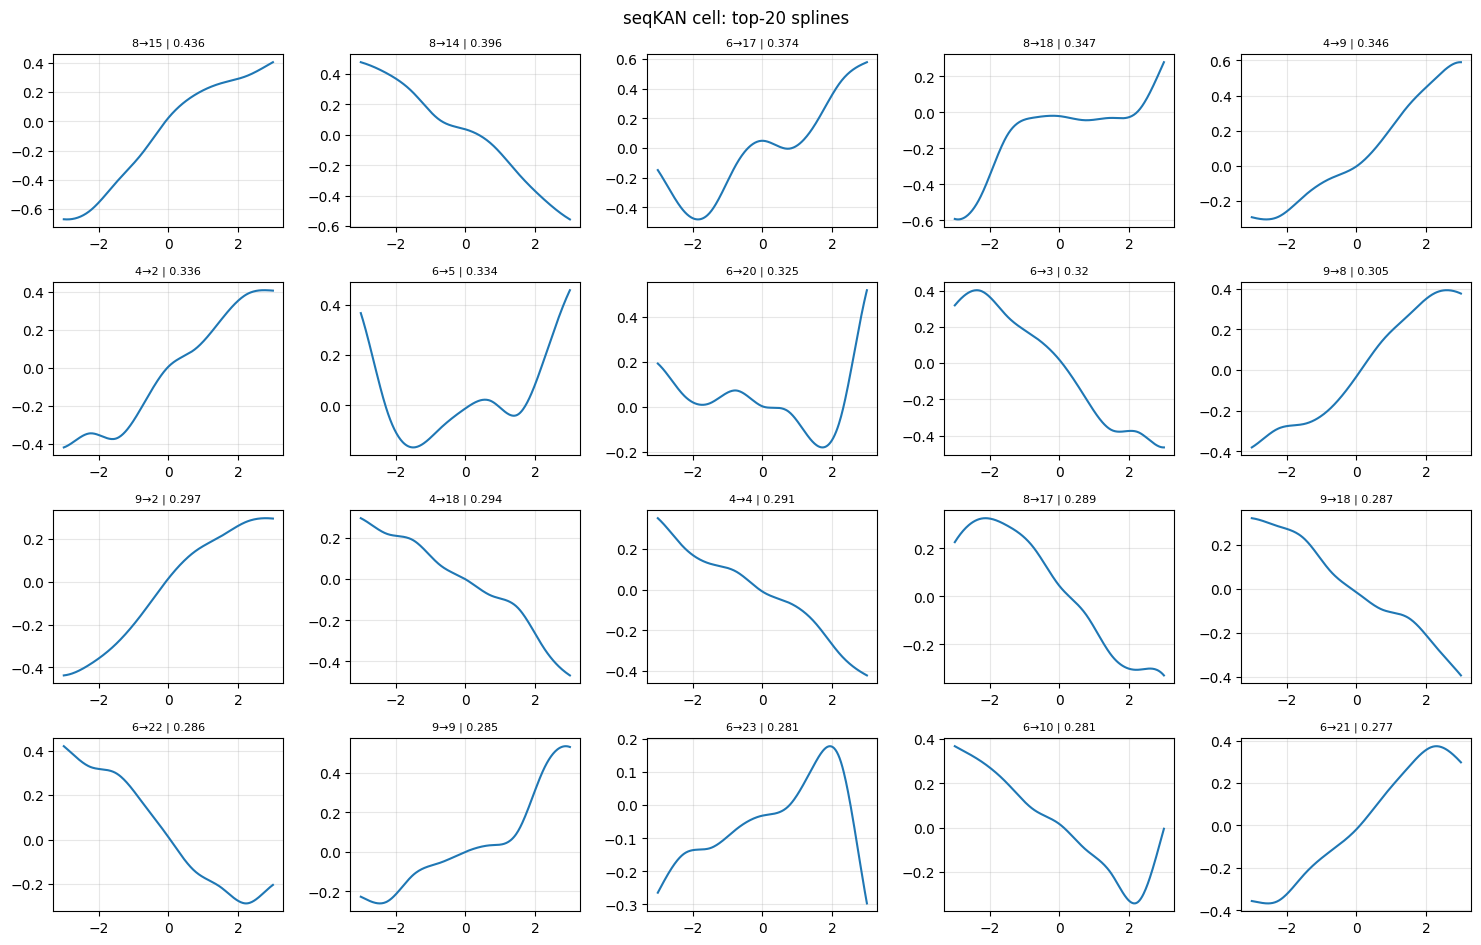

[TF] plot de spline da saída indisponível (kan_out=Linear).


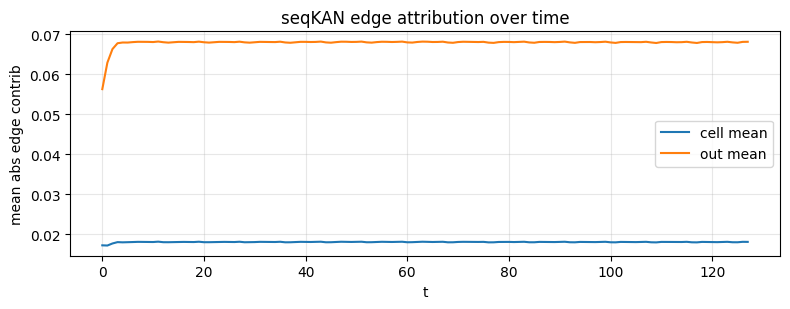

,model,TF_core_claim,TF_topk_mass_ratio,EA_method,EA_spearman_mean,EA_spearman_std,SE_seqkan_sparsity_eps,SE_gru_compress_q90,AD_pass_rate,AD_rules_n
0,seqKAN,1.0,0.137532,gradxinput,0.500684,0.000559,0.282143,NaN,0.333333,3
1,GRU,0.0,NaN,gradxinput,0.500684,0.000559,NaN,0.900019,0.333333,3


Saved explainability_v2 CSVs in: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results


In [26]:
# --- EXPLAINABILITY_V2: TF(core)+TopK, EA robusta, SE corrigida, AD por regras ---
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

# ============================================================
# 0) utilidades
# ============================================================

def _device(model):
    return next(model.parameters()).device


def _to_dev(model, x, ts, m):
    d = _device(model)
    return x.to(d), ts.to(d), m.to(d)


def _xhat(model, x, ts, m):
    model.eval()
    x, ts, m = _to_dev(model, x, ts, m)
    with torch.no_grad():
        out = model.forward(x, timestamps=ts, return_x_hat=True, mask=m, test=True)
    return out[3]


def _spearman(a, b):
    ra = pd.Series(np.asarray(a)).rank(method='average').to_numpy()
    rb = pd.Series(np.asarray(b)).rank(method='average').to_numpy()
    sa, sb = np.std(ra), np.std(rb)
    if sa < 1e-12 or sb < 1e-12:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])


def _make_eval_batch(model, df, feature_cols, timestamp_col='index', window_size=128, window_step=8, max_windows=256):
    ds = model._make_dataset(
        df=df,
        timestamp_col=timestamp_col,
        window_size=window_size,
        feature_cols=feature_cols,
        static_features_cols=None,
        window_step=window_step,
        df_denoised=None,
        predict_state_cols=None,
    )
    seqs, ts_seqs, mask_seqs = ds.tensors[:3]
    n = min(max_windows, seqs.shape[0])
    return seqs[:n], ts_seqs[:n], mask_seqs[:n]


# ============================================================
# 1) IMPORTÂNCIA comparável (gradxinput / IG / permutation)
# ============================================================

def _attr_gradxinput(model, x, ts, m):
    model.eval()
    x, ts, m = _to_dev(model, x, ts, m)
    xg = x.detach().clone().requires_grad_(True)
    out = model.forward(xg, timestamps=ts, return_x_hat=True, mask=m, test=True)
    y = out[3][:, -1, :].mean()
    g = torch.autograd.grad(y, xg, retain_graph=False, create_graph=False)[0]
    imp = (g * xg).abs().mean(dim=(0, 1))
    return imp.detach().cpu().numpy()


def _attr_integrated_gradients(model, x, ts, m, steps=24):
    model.eval()
    x, ts, m = _to_dev(model, x, ts, m)
    baseline = torch.zeros_like(x)
    total_grad = torch.zeros_like(x)

    for alpha in torch.linspace(0, 1, steps, device=x.device):
        xi = baseline + alpha * (x - baseline)
        xi.requires_grad_(True)
        out = model.forward(xi, timestamps=ts, return_x_hat=True, mask=m, test=True)
        y = out[3][:, -1, :].mean()
        grad = torch.autograd.grad(y, xi, retain_graph=False, create_graph=False)[0]
        total_grad = total_grad + grad

    ig = (x - baseline) * total_grad / float(steps)
    imp = ig.abs().mean(dim=(0, 1))
    return imp.detach().cpu().numpy()


def _attr_permutation(model, x, ts, m, seed=0):
    # importância por aumento de erro quando permuta uma feature no batch
    rng = np.random.default_rng(seed)
    model.eval()
    x, ts, m = _to_dev(model, x, ts, m)
    with torch.no_grad():
        pred0 = _xhat(model, x, ts, m)
        base_mse = ((pred0 - x) ** 2).mean().item()

    C = x.shape[-1]
    imps = np.zeros(C, dtype=float)
    for c in range(C):
        xp = x.clone()
        idx = torch.tensor(rng.permutation(x.shape[0]), device=x.device)
        xp[:, :, c] = xp[idx, :, c]
        with torch.no_grad():
            pred = _xhat(model, xp, ts, m)
            mse = ((pred - x) ** 2).mean().item()
        imps[c] = mse - base_mse
    return imps



def _attr_permutation_window(model, x, ts, m, seed=0):
    # permutação temporal por janela (window-wise): mede delta de erro por feature
    rng = np.random.default_rng(seed)
    model.eval()
    x, ts, m = _to_dev(model, x, ts, m)
    with torch.no_grad():
        pred0 = _xhat(model, x, ts, m)
        base_mse_w = ((pred0 - x) ** 2).mean(dim=(1, 2))

    B, T, C = x.shape
    imps = np.zeros(C, dtype=float)
    for c in range(C):
        xp = x.clone()
        for b in range(B):
            idx_t = torch.tensor(rng.permutation(T), device=x.device)
            xp[b, :, c] = xp[b, idx_t, c]
        with torch.no_grad():
            pred = _xhat(model, xp, ts, m)
            mse_w = ((pred - x) ** 2).mean(dim=(1, 2))
        imps[c] = float((mse_w - base_mse_w).mean().item())
    return imps


def feature_importance(model, x, ts, m, method='gradxinput', seed=0):
    method = method.lower()
    if method == 'gradxinput':
        return _attr_gradxinput(model, x, ts, m)
    if method in ('ig', 'integrated_gradients'):
        return _attr_integrated_gradients(model, x, ts, m)
    if method == 'permutation':
        return _attr_permutation(model, x, ts, m, seed=seed)
    if method in ('permutation_window', 'window_permutation', 'perm_window'):
        return _attr_permutation_window(model, x, ts, m, seed=seed)
    raise ValueError('method deve ser gradxinput, ig, permutation ou permutation_window')


# ============================================================
# 2) TF (core) + segunda evidência top-k (seqKAN)
# ============================================================

def _edge_score_from_layer(layer, score='coef_l2'):
    if hasattr(layer, 'coef') and layer.coef is not None:
        coef = layer.coef.detach()
        if score in ('coef_l1', 'coef_abs'):
            s = coef.abs().mean(dim=-1)
        else:
            s = torch.sqrt((coef ** 2).mean(dim=-1) + 1e-12)
        return s
    if hasattr(layer, 'scale_sp') and layer.scale_sp is not None:
        return layer.scale_sp.detach().abs()
    raise ValueError('layer sem coef/scale_sp')


def _align_in_out(layer, scores):
    in_dim = layer.grid.shape[0]
    if scores.shape[0] == in_dim:
        return scores
    if scores.shape[1] == in_dim:
        return scores.T
    raise ValueError(f'shape invalida scores={scores.shape}, in_dim={in_dim}')


def topk_edges_and_mass(layer, k=20, score='coef_l2'):
    s = _align_in_out(layer, _edge_score_from_layer(layer, score=score))
    s = s.detach().cpu()
    flat = s.reshape(-1)
    kk = min(int(k), flat.numel())
    vals, idx = torch.topk(flat, k=kk)

    out_dim = s.shape[1]
    edges = []
    for v, f in zip(vals.tolist(), idx.tolist()):
        i = int(f // out_dim)
        j = int(f % out_dim)
        edges.append({'i_in': i, 'j_out': j, 'score': float(v)})

    total_mass = float(flat.abs().sum().item())
    topk_mass = float(vals.abs().sum().item())
    mass_ratio = topk_mass / max(total_mass, 1e-12)
    return edges, mass_ratio


def topk_edges_and_mass_linear(linear_layer, k=20):
    # Linear: weight shape (out_dim, in_dim) -> converte para (in_dim, out_dim)
    w = linear_layer.weight.detach().abs().T.cpu()
    flat = w.reshape(-1)
    kk = min(int(k), flat.numel())
    vals, idx = torch.topk(flat, k=kk)

    out_dim = w.shape[1]
    edges = []
    for v, f in zip(vals.tolist(), idx.tolist()):
        i = int(f // out_dim)
        j = int(f % out_dim)
        edges.append({'i_in': i, 'j_out': j, 'score': float(v)})

    total_mass = float(flat.sum().item())
    topk_mass = float(vals.sum().item())
    mass_ratio = topk_mass / max(total_mass, 1e-12)
    return edges, mass_ratio


def sample_spline(layer, i_in, j_out, n=300):
    k = int(layer.k)
    # usa CPU só para construir range de plot
    grid_cpu = layer.grid[i_in].detach().cpu().numpy()
    x_min, x_max = grid_cpu[k], grid_cpu[-k-1]
    x = np.linspace(x_min, x_max, n)

    # garante que x/grid/coef estejam no mesmo device
    dev = layer.grid.device
    x_t = torch.tensor(x, dtype=layer.grid.dtype, device=dev).view(-1, 1)
    grid_t = layer.grid[i_in:i_in+1]
    coef_t = layer.coef[i_in:i_in+1, j_out:j_out+1]

    with torch.no_grad():
        y = coef2curve(x_t, grid_t, coef_t, layer.k)[:, 0, 0]
        if hasattr(layer, 'mask') and layer.mask is not None:
            y = y * layer.mask[i_in, j_out]
    return x, y.detach().cpu().numpy()


def plot_topk_splines(layer, edges, title='Top-k splines', n_show=20, ncols=5):
    show = edges[:n_show]
    n = len(show)
    nrows = int(np.ceil(n / ncols)) if n > 0 else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.0, nrows*2.4))
    axes = np.array(axes).reshape(-1)

    for ax, e in zip(axes, show):
        x, y = sample_spline(layer, e['i_in'], e['j_out'])
        ax.plot(x, y)
        ax.set_title(f"{e['i_in']}→{e['j_out']} | {e['score']:.3g}", fontsize=8)
        ax.grid(True, alpha=0.3)
    for ax in axes[len(show):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()
    return fig


def tf_metrics(seqkan_model, topk=20):
    layer_cell = seqkan_model.seqKAN.kan_cell.act_fun[0]

    edges_cell, mass_cell = topk_edges_and_mass(layer_cell, k=topk)

    out_mod = seqkan_model.seqKAN.kan_out
    if hasattr(out_mod, 'act_fun'):
        layer_out = out_mod.act_fun[0]
        edges_out, mass_out = topk_edges_and_mass(layer_out, k=topk)
        out_kind = 'kan'
    elif isinstance(out_mod, torch.nn.Linear):
        edges_out, mass_out = topk_edges_and_mass_linear(out_mod, k=topk)
        out_kind = 'linear'
    else:
        edges_out, mass_out = [], np.nan
        out_kind = type(out_mod).__name__

    # TF core claim
    tf_core = 1.0

    # segunda evidência
    tf_topk_mass = float(np.nanmean([mass_cell, mass_out]))

    return {
        'tf_core_claim': tf_core,
        'tf_topk_mass_ratio': tf_topk_mass,
        'tf_topk_mass_cell': float(mass_cell),
        'tf_topk_mass_out': float(mass_out) if not np.isnan(mass_out) else np.nan,
        'tf_out_kind': out_kind,
        'top_edges_cell': edges_cell,
        'top_edges_out': edges_out,
    }


# ============================================================
# 3) EA robusta (ruído 0.5%~2%, seeds, múltiplas janelas)
# ============================================================

def ea_stability(model, x, ts, m, method='gradxinput',
                 noise_pcts=(0.005, 0.01, 0.02),
                 n_seeds=5, windows_per_seed=32):
    x = x.detach()
    ts = ts.detach()
    m = m.detach()

    N = x.shape[0]
    C = x.shape[-1]
    x_np = x.cpu().numpy()
    feat_range = x_np.reshape(-1, C).ptp(axis=0) + 1e-12

    vals = []
    for s in range(n_seeds):
        rng = np.random.default_rng(100 + s)
        take = min(windows_per_seed, N)
        idx = rng.choice(N, size=take, replace=False)

        xw = x[idx]
        tsw = ts[idx]
        mw = m[idx]

        base = feature_importance(model, xw, tsw, mw, method=method, seed=100 + s)

        for pct in noise_pcts:
            noise = rng.normal(loc=0.0, scale=(pct * feat_range), size=xw.shape)
            noise_t = torch.tensor(noise, dtype=xw.dtype, device=xw.device)
            xp = xw + noise_t
            pert = feature_importance(model, xp, tsw, mw, method=method, seed=200 + s)
            vals.append(_spearman(base, pert))

    vals = np.array(vals, dtype=float)
    return {
        'ea_method': method,
        'ea_spearman_mean': float(np.nanmean(vals)),
        'ea_spearman_std': float(np.nanstd(vals)),
        'ea_n_eval': int(np.sum(~np.isnan(vals))),
    }


def ea_permutation_window_importance(model, x, ts, m, n_seeds=5, windows_per_seed=32):
    # importância por janela para evidenciar separação entre arquiteturas
    x = x.detach()
    ts = ts.detach()
    m = m.detach()
    N = x.shape[0]
    C = x.shape[-1]

    records = []
    all_imps = []

    for s in range(n_seeds):
        rng = np.random.default_rng(300 + s)
        take = min(windows_per_seed, N)
        idx = rng.choice(N, size=take, replace=False)
        xw = x[idx]
        tsw = ts[idx]
        mw = m[idx]

        imp = feature_importance(model, xw, tsw, mw, method='permutation_window', seed=400 + s)
        all_imps.append(imp)
        for c in range(C):
            records.append({
                'seed': int(s),
                'feature': int(c),
                'importance': float(imp[c]),
            })

    arr = np.array(all_imps, dtype=float)
    mean_imp = np.nanmean(arr, axis=0) if arr.size else np.zeros(C)
    std_imp = np.nanstd(arr, axis=0) if arr.size else np.zeros(C)

    df = pd.DataFrame(records)
    df_summary = pd.DataFrame({
        'feature': np.arange(C, dtype=int),
        'importance_mean': mean_imp,
        'importance_std': std_imp,
    }).sort_values('importance_mean', ascending=False, ignore_index=True)

    return {
        'df_window_importance': df,
        'df_window_importance_summary': df_summary,
    }


# ============================================================
# 4) SE corrigida
#    - seqKAN: arestas com contribuição > eps
#    - GRU: compressibilidade (pruning proxy)
# ============================================================

def _seqkan_hidden_size(seq):
    hs = getattr(seq, 'hidden_size', None)
    if hs is None:
        hs = getattr(seq, 'hidden_dim', None)
    if hs is None:
        raise AttributeError('seqKAN sem hidden_size/hidden_dim')
    return int(hs)


def _build_seqkan_h_input(seq, x_t, h, m_t):
    # Compatível com variantes: com kan_encoder (z_t) e sem kan_encoder (x_t direto)
    cand = []
    if hasattr(seq, 'kan_encoder'):
        try:
            z_t = seq.kan_encoder(x_t)
            cand.append(z_t)
        except Exception:
            pass
    cand.append(x_t)

    expected = None
    if hasattr(seq, 'kan_cell') and hasattr(seq.kan_cell, 'act_fun') and len(seq.kan_cell.act_fun) > 0:
        layer0 = seq.kan_cell.act_fun[0]
        if hasattr(layer0, 'grid'):
            expected = int(layer0.grid.shape[0])

    for base in cand:
        h_in = torch.cat([base, h, m_t], dim=-1)
        if expected is None or h_in.shape[-1] == expected:
            return h_in

    return torch.cat([cand[0], h, m_t], dim=-1)


def _seqkan_edge_contrib_mean(seqkan_model, x, ts, m):
    # contribuição média abs por aresta (cell e out) usando trajetória real
    seq = seqkan_model.seqKAN
    x, ts, m = _to_dev(seqkan_model, x, ts, m)
    B, T, C = x.shape
    hs = _seqkan_hidden_size(seq)
    h = torch.zeros(B, hs, device=x.device, dtype=x.dtype)

    layer_c = seq.kan_cell.act_fun[0]
    out_mod = seq.kan_out

    acc_c = torch.zeros(layer_c.grid.shape[0], layer_c.coef.shape[1], device=x.device)
    if hasattr(out_mod, 'act_fun'):
        layer_o = out_mod.act_fun[0]
        acc_o = torch.zeros(layer_o.grid.shape[0], layer_o.coef.shape[1], device=x.device)
        out_kind = 'kan'
    elif isinstance(out_mod, torch.nn.Linear):
        w_t = out_mod.weight.T  # (hidden, out)
        acc_o = torch.zeros(w_t.shape[0], w_t.shape[1], device=x.device)
        out_kind = 'linear'
    else:
        acc_o = torch.zeros(1, 1, device=x.device)
        out_kind = 'unknown'

    with torch.no_grad():
        mask_z = seq.mask_proj((1 - m))
        for t in range(T):
            x_t = x[:, t, :]
            m_t = mask_z[:, t, :] * h
            h_in = _build_seqkan_h_input(seq, x_t, h, m_t)

            yc = coef2curve(h_in, layer_c.grid, layer_c.coef, layer_c.k)
            yc = yc * layer_c.mask[None, :, :]
            acc_c += yc.abs().mean(dim=0)

            h = seq.kan_cell(h_in)

            if out_kind == 'kan':
                yo = coef2curve(h, layer_o.grid, layer_o.coef, layer_o.k)
                yo = yo * layer_o.mask[None, :, :]
                acc_o += yo.abs().mean(dim=0)
            elif out_kind == 'linear':
                # contribuição por aresta hidden->out: |h_i * w_{i,j}|
                yo = (h[:, :, None] * w_t[None, :, :]).abs()
                acc_o += yo.mean(dim=0)

    acc_c = acc_c / max(T, 1)
    acc_o = acc_o / max(T, 1)
    return acc_c.detach().cpu().numpy(), acc_o.detach().cpu().numpy()



def seqkan_edge_attribution_time(seqkan_model, x, ts, m, max_windows=64):
    # contribuição das arestas ao longo do tempo (cell vs out)
    seq = seqkan_model.seqKAN
    x = x[:max_windows]
    ts = ts[:max_windows]
    m = m[:max_windows]
    x, ts, m = _to_dev(seqkan_model, x, ts, m)

    B, T, _ = x.shape
    hs = _seqkan_hidden_size(seq)
    h = torch.zeros(B, hs, device=x.device, dtype=x.dtype)

    layer_c = seq.kan_cell.act_fun[0]
    out_mod = seq.kan_out
    if hasattr(out_mod, 'act_fun'):
        layer_o = out_mod.act_fun[0]
        out_kind = 'kan'
    elif isinstance(out_mod, torch.nn.Linear):
        w_t = out_mod.weight.T
        out_kind = 'linear'
    else:
        out_kind = 'unknown'

    rec = []
    with torch.no_grad():
        mask_z = seq.mask_proj((1 - m))
        for t in range(T):
            x_t = x[:, t, :]
            m_t = mask_z[:, t, :] * h
            h_in = _build_seqkan_h_input(seq, x_t, h, m_t)

            yc = coef2curve(h_in, layer_c.grid, layer_c.coef, layer_c.k)
            yc = yc * layer_c.mask[None, :, :]
            yo_prev = yc.abs().mean(dim=0)

            h = seq.kan_cell(h_in)

            if out_kind == 'kan':
                yo = coef2curve(h, layer_o.grid, layer_o.coef, layer_o.k)
                yo = yo * layer_o.mask[None, :, :]
                yo_cur = yo.abs().mean(dim=0)
            elif out_kind == 'linear':
                yo_cur = (h[:, :, None] * w_t[None, :, :]).abs().mean(dim=0)
            else:
                yo_cur = torch.zeros(1, 1, device=x.device)

            rec.append({
                't': int(t),
                'cell_edge_contrib_mean': float(yo_prev.mean().item()),
                'cell_edge_contrib_max': float(yo_prev.max().item()),
                'out_edge_contrib_mean': float(yo_cur.mean().item()),
                'out_edge_contrib_max': float(yo_cur.max().item()),
            })

    return pd.DataFrame(rec)

def se_seqkan_used_edges(seqkan_model, x, ts, m, eps_frac=0.01):
    cc, co = _seqkan_edge_contrib_mean(seqkan_model, x, ts, m)
    allc = np.concatenate([cc.reshape(-1), co.reshape(-1)])
    eps = float(eps_frac * np.max(allc)) if allc.size else 0.0
    used = float(np.sum(allc > eps))
    total = float(allc.size)
    sparsity = 1.0 - used / max(total, 1.0)
    return {
        'se_seqkan_used_edges': used,
        'se_seqkan_total_edges': total,
        'se_seqkan_sparsity_eps': sparsity,
        'se_seqkan_eps': eps,
    }


def gru_compressibility(gru_model, quantiles=(0.5, 0.8, 0.9, 0.95)):
    ws = []
    for p in gru_model.parameters():
        if p.requires_grad:
            ws.append(p.detach().abs().reshape(-1).cpu())
    if not ws:
        return {'gru_compressibility': {}}
    w = torch.cat(ws).numpy()
    out = {}
    for q in quantiles:
        thr = float(np.quantile(w, q))
        frac = float(np.mean(w <= thr))
        out[f'q{int(q*100)}'] = {'threshold': thr, 'compressible_fraction': frac}
    return {'gru_compressibility': out}


# ============================================================
# 5) AD com regras defensáveis
# ============================================================

def _pd_curve(model, x, ts, m, feat_idx, out_idx, vmin, vmax, n=50):
    grid = np.linspace(float(vmin), float(vmax), int(n))
    ys = []
    for v in grid:
        x2 = x.clone()
        x2[:, :, feat_idx] = v
        y = _xhat(model, x2, ts, m)[:, -1, out_idx].mean().item()
        ys.append(y)
    return grid, np.array(ys, dtype=float)


def _rule_monotonic(model, x, ts, m, rule):
    g, y = _pd_curve(model, x, ts, m, rule['feature'], rule['output'], rule['vmin'], rule['vmax'], rule.get('n', 50))
    dy = np.diff(y)
    exp = rule.get('expected', 'increasing')
    if exp == 'increasing':
        score = float(np.mean(dy >= 0))
    else:
        score = float(np.mean(dy <= 0))
    thr = float(rule.get('threshold', 0.8))
    return score >= thr, score


def _rule_saturation(model, x, ts, m, rule):
    g, y = _pd_curve(model, x, ts, m, rule['feature'], rule['output'], rule['vmin'], rule['vmax'], rule.get('n', 60))
    dy = np.abs(np.diff(y))
    sat_after = float(rule['sat_after'])
    idx = np.searchsorted(g, sat_after)
    idx = min(max(idx, 2), len(dy)-2)
    slope_after = float(np.mean(dy[idx:]))
    slope_before = float(np.mean(dy[:idx]))
    ratio = slope_after / max(slope_before, 1e-12)
    tol = float(rule.get('max_ratio', 0.3))
    return ratio <= tol, ratio


def _rule_sign_consistency(model, x, ts, m, rule):
    # aumento de carga -> aumento de potência etc.
    lo = float(rule['v_lo'])
    hi = float(rule['v_hi'])
    out_idx = int(rule['output'])
    feat = int(rule['feature'])
    x_lo = x.clone(); x_lo[:, :, feat] = lo
    x_hi = x.clone(); x_hi[:, :, feat] = hi
    y_lo = _xhat(model, x_lo, ts, m)[:, -1, out_idx].mean().item()
    y_hi = _xhat(model, x_hi, ts, m)[:, -1, out_idx].mean().item()
    delta = y_hi - y_lo
    exp = rule.get('expected', 'positive')
    ok = (delta >= 0) if exp == 'positive' else (delta <= 0)
    return bool(ok), float(delta)


def ad_rules_eval(model, x, ts, m, rules):
    if rules is None:
        rules = []

    details = []
    for r in rules:
        rtype = r.get('type', 'monotonic')
        if rtype == 'monotonic':
            ok, metric = _rule_monotonic(model, x, ts, m, r)
        elif rtype == 'saturation':
            ok, metric = _rule_saturation(model, x, ts, m, r)
        elif rtype == 'sign_consistency':
            ok, metric = _rule_sign_consistency(model, x, ts, m, r)
        else:
            raise ValueError(f'tipo de regra desconhecido: {rtype}')
        details.append({'type': rtype, 'ok': bool(ok), 'metric': float(metric), **r})

    n = len(details)
    n_ok = int(sum(d['ok'] for d in details))
    rate = float(n_ok / n) if n > 0 else np.nan
    return {
        'ad_pass_rate': rate,
        'ad_rules_ok': n_ok,
        'ad_rules_n': n,
        'ad_details': details,
    }


# ============================================================
# 6) Benchmark consolidado
# ============================================================

def explainability_benchmark_v2(seqkan_model, gru_model, x, ts, m,
                                topk=20,
                                ea_method='gradxinput',
                                ea_extra_methods=('ig', 'permutation_window'),
                                ea_noise_pcts=(0.005, 0.01, 0.02),
                                ea_n_seeds=5,
                                ea_windows_per_seed=32,
                                se_eps_frac=0.01,
                                ad_rules=None,
                                compute_seqkan_edge_time=True,
                                edge_time_max_windows=64,
                                make_plots=True):
    ad_rules = ad_rules or []

    # TF
    tf = tf_metrics(seqkan_model, topk=topk)

    # EA principal (comparável, mesmo método)
    ea_seq = ea_stability(seqkan_model, x, ts, m, method=ea_method,
                          noise_pcts=ea_noise_pcts, n_seeds=ea_n_seeds,
                          windows_per_seed=ea_windows_per_seed)
    ea_gru = ea_stability(gru_model, x, ts, m, method=ea_method,
                          noise_pcts=ea_noise_pcts, n_seeds=ea_n_seeds,
                          windows_per_seed=ea_windows_per_seed)

    # EA extra para aumentar separação seqKAN vs GRU
    ea_compare_rows = []
    methods = [ea_method] + [m for m in (ea_extra_methods or []) if m != ea_method]
    for meth in methods:
        seq_m = ea_stability(seqkan_model, x, ts, m, method=meth,
                             noise_pcts=ea_noise_pcts, n_seeds=ea_n_seeds,
                             windows_per_seed=ea_windows_per_seed)
        gru_m = ea_stability(gru_model, x, ts, m, method=meth,
                             noise_pcts=ea_noise_pcts, n_seeds=ea_n_seeds,
                             windows_per_seed=ea_windows_per_seed)
        ea_compare_rows.append({
            'EA_method': meth,
            'seqKAN_spearman_mean': seq_m['ea_spearman_mean'],
            'GRU_spearman_mean': gru_m['ea_spearman_mean'],
            'delta_seq_minus_gru': seq_m['ea_spearman_mean'] - gru_m['ea_spearman_mean'],
        })

    df_ea_compare = pd.DataFrame(ea_compare_rows).sort_values('delta_seq_minus_gru', ascending=False, ignore_index=True)

    # permutation importance por janela (resumo por feature)
    seq_perm = ea_permutation_window_importance(seqkan_model, x, ts, m,
                                                n_seeds=ea_n_seeds,
                                                windows_per_seed=ea_windows_per_seed)
    gru_perm = ea_permutation_window_importance(gru_model, x, ts, m,
                                                n_seeds=ea_n_seeds,
                                                windows_per_seed=ea_windows_per_seed)

    df_perm_seq = seq_perm['df_window_importance_summary'].copy()
    df_perm_seq['model'] = 'seqKAN'
    df_perm_gru = gru_perm['df_window_importance_summary'].copy()
    df_perm_gru['model'] = 'GRU'
    df_perm_window_summary = pd.concat([df_perm_seq, df_perm_gru], ignore_index=True)

    # edge attribution temporal do seqKAN
    if compute_seqkan_edge_time:
        df_edge_time = seqkan_edge_attribution_time(
            seqkan_model, x, ts, m, max_windows=edge_time_max_windows
        )
    else:
        df_edge_time = pd.DataFrame()

    # SE
    se_seq = se_seqkan_used_edges(seqkan_model, x, ts, m, eps_frac=se_eps_frac)
    se_gru = gru_compressibility(gru_model)

    # AD
    ad_seq = ad_rules_eval(seqkan_model, x, ts, m, ad_rules)
    ad_gru = ad_rules_eval(gru_model, x, ts, m, ad_rules)

    # tabela principal (compacta)
    rows = []
    rows.append({
        'model': 'seqKAN',
        'TF_core_claim': tf['tf_core_claim'],
        'TF_topk_mass_ratio': tf['tf_topk_mass_ratio'],
        'EA_method': ea_seq['ea_method'],
        'EA_spearman_mean': ea_seq['ea_spearman_mean'],
        'EA_spearman_std': ea_seq['ea_spearman_std'],
        'SE_seqkan_sparsity_eps': se_seq['se_seqkan_sparsity_eps'],
        'SE_gru_compress_q90': np.nan,
        'AD_pass_rate': ad_seq['ad_pass_rate'],
        'AD_rules_n': ad_seq['ad_rules_n'],
    })
    q90 = se_gru['gru_compressibility'].get('q90', {}).get('compressible_fraction', np.nan)
    rows.append({
        'model': 'GRU',
        'TF_core_claim': 0.0,
        'TF_topk_mass_ratio': np.nan,
        'EA_method': ea_gru['ea_method'],
        'EA_spearman_mean': ea_gru['ea_spearman_mean'],
        'EA_spearman_std': ea_gru['ea_spearman_std'],
        'SE_seqkan_sparsity_eps': np.nan,
        'SE_gru_compress_q90': q90,
        'AD_pass_rate': ad_gru['ad_pass_rate'],
        'AD_rules_n': ad_gru['ad_rules_n'],
    })

    df_main = pd.DataFrame(rows)

    # evidência TF extra
    df_top_cell = pd.DataFrame(tf['top_edges_cell'])
    df_top_out = pd.DataFrame(tf['top_edges_out'])

    if make_plots:
        layer_cell = seqkan_model.seqKAN.kan_cell.act_fun[0]
        plot_topk_splines(layer_cell, tf['top_edges_cell'], title=f'seqKAN cell: top-{topk} splines', n_show=min(topk, 20))

        out_mod = seqkan_model.seqKAN.kan_out
        if hasattr(out_mod, 'act_fun'):
            layer_out = out_mod.act_fun[0]
            plot_topk_splines(layer_out, tf['top_edges_out'], title=f'seqKAN out: top-{topk} splines', n_show=min(topk, 20))
        else:
            print(f"[TF] plot de spline da saída indisponível (kan_out={type(out_mod).__name__}).")

        if not df_edge_time.empty:
            plt.figure(figsize=(8, 3.2))
            plt.plot(df_edge_time['t'], df_edge_time['cell_edge_contrib_mean'], label='cell mean')
            plt.plot(df_edge_time['t'], df_edge_time['out_edge_contrib_mean'], label='out mean')
            plt.title('seqKAN edge attribution over time')
            plt.xlabel('t')
            plt.ylabel('mean abs edge contrib')
            plt.grid(alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

    artifacts = {
        'df_main': df_main,
        'df_top_edges_cell': df_top_cell,
        'df_top_edges_out': df_top_out,
        'df_ea_compare': df_ea_compare,
        'df_perm_window_summary': df_perm_window_summary,
        'df_perm_window_seq': seq_perm['df_window_importance'],
        'df_perm_window_gru': gru_perm['df_window_importance'],
        'df_seqkan_edge_time': df_edge_time,
        'ad_seq_details': pd.DataFrame(ad_seq['ad_details']) if ad_seq['ad_details'] else pd.DataFrame(),
        'ad_gru_details': pd.DataFrame(ad_gru['ad_details']) if ad_gru['ad_details'] else pd.DataFrame(),
        'se_seq': se_seq,
        'se_gru': se_gru,
        'tf': tf,
        'ea_seq': ea_seq,
        'ea_gru': ea_gru,
    }
    return artifacts


# ============================================================
# 7) USO (ajuste regras de domínio)
# ============================================================
# pega modelos do notebook atual
_seq = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
_gru = globals().get('gru_model', globals().get('model_tsdf_gru', None))
if _seq is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model).')
if _gru is None:
    raise ValueError('GRU não encontrado em memória (gru_model).')
if 'dl' not in globals():
    raise ValueError('dl.df não encontrado.')
if 'feature_cols' not in globals():
    feature_cols = list(dl.df.columns[:-3])

x_eval, ts_eval, m_eval = _make_eval_batch(_seq, dl.df, feature_cols, timestamp_col='index', window_size=128, window_step=8, max_windows=256)

# Regras simples industrialmente defensáveis (EXEMPLO; ajuste índices e limites)
ad_rules = [
    # monotonicidade esperada
    {'type': 'monotonic', 'feature': 1, 'output': 1, 'expected': 'increasing', 'vmin': -3.0, 'vmax': 3.0, 'threshold': 0.8},
    # saturação após limite operacional
    {'type': 'saturation', 'feature': 0, 'output': 0, 'vmin': -3.0, 'vmax': 3.0, 'sat_after': 1.5, 'max_ratio': 0.35},
    # consistência de sinal (carga↑ -> potência↑)
    {'type': 'sign_consistency', 'feature': 2, 'output': 1, 'v_lo': -1.0, 'v_hi': 1.0, 'expected': 'positive'},
]

art = explainability_benchmark_v2(
    seqkan_model=_seq,
    gru_model=_gru,
    x=x_eval,
    ts=ts_eval,
    m=m_eval,
    topk=20,
    ea_method='gradxinput',      # método principal (mantido)
    ea_extra_methods=('ig', 'permutation_window'),
    ea_noise_pcts=(0.005, 0.01, 0.02),
    ea_n_seeds=5,
    ea_windows_per_seed=32,
    se_eps_frac=0.01,
    ad_rules=ad_rules,
    compute_seqkan_edge_time=True,
    edge_time_max_windows=64,
    make_plots=True,
)

display(art['df_main'])

# salvas para artigo
out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'
art['df_main'].to_csv(f"{out_dir}/explainability_v2_main.csv", index=False)
art['df_top_edges_cell'].to_csv(f"{out_dir}/explainability_v2_top_edges_cell.csv", index=False)
art['df_top_edges_out'].to_csv(f"{out_dir}/explainability_v2_top_edges_out.csv", index=False)
if not art['ad_seq_details'].empty:
    art['ad_seq_details'].to_csv(f"{out_dir}/explainability_v2_ad_seqkan_details.csv", index=False)
if not art['ad_gru_details'].empty:
    art['ad_gru_details'].to_csv(f"{out_dir}/explainability_v2_ad_gru_details.csv", index=False)

print('Saved explainability_v2 CSVs in:', out_dir)





## RUNBOOK (ordem de execução limpa)

Execute **somente** nesta ordem:

1. `# --- CHECKPOINT_LOADER_V2 (nao sobrescreve suas celulas) ---`
2. `# --- EXPLAINABILITY_V2: TF(core)+TopK, EA robusta, SE corrigida, AD por regras ---` (célula de definições)
3. `STEP-AD-RULES` (célula abaixo, com índices já ajustados)
4. `STEP-RUN-BENCHMARK-V2` (célula abaixo, executa e salva CSVs)

Ignore as células antigas de benchmark anteriores a esta seção.


In [10]:
# STEP-AD-RULES (ajustado para suas features atuais)
# 0 PH (CBM) 1st Stage ExpPress Ratio
# 2 PH (CBM) 1st Stage ActShaft Power
# 8 PH (CBM) 1st Stage ExpShaft Power
# 9 PH (CBM) 1st Stage ActPress Ratio

ad_rules = [
    {
        'type': 'sign_consistency',
        'feature': 0,
        'output': 2,
        'v_lo': -1.0,
        'v_hi': 1.0,
        'expected': 'positive',
        'note': 'ExpPress Ratio -> ActShaft Power',
    },
    {
        'type': 'monotonic',
        'feature': 0,
        'output': 9,
        'expected': 'increasing',
        'vmin': -3.0,
        'vmax': 3.0,
        'threshold': 0.8,
        'n': 50,
        'note': 'ExpPress Ratio -> ActPress Ratio',
    },
    {
        'type': 'saturation',
        'feature': 0,
        'output': 2,
        'vmin': -3.0,
        'vmax': 3.0,
        'sat_after': 1.5,
        'max_ratio': 0.35,
        'n': 60,
        'note': 'Saturation of power at high pressure ratio',
    },
    {
        'type': 'sign_consistency',
        'feature': 8,
        'output': 2,
        'v_lo': -1.0,
        'v_hi': 1.0,
        'expected': 'positive',
        'note': 'ExpShaft Power -> ActShaft Power',
    },
]

print('ad_rules prontas:', len(ad_rules))
for r in ad_rules:
    print('-', r['type'], '| f', r['feature'], '-> out', r['output'], '|', r.get('note',''))



ad_rules prontas: 4
- sign_consistency | f 0 -> out 2 | ExpPress Ratio -> ActShaft Power
- monotonic | f 0 -> out 9 | ExpPress Ratio -> ActPress Ratio
- saturation | f 0 -> out 2 | Saturation of power at high pressure ratio
- sign_consistency | f 8 -> out 2 | ExpShaft Power -> ActShaft Power


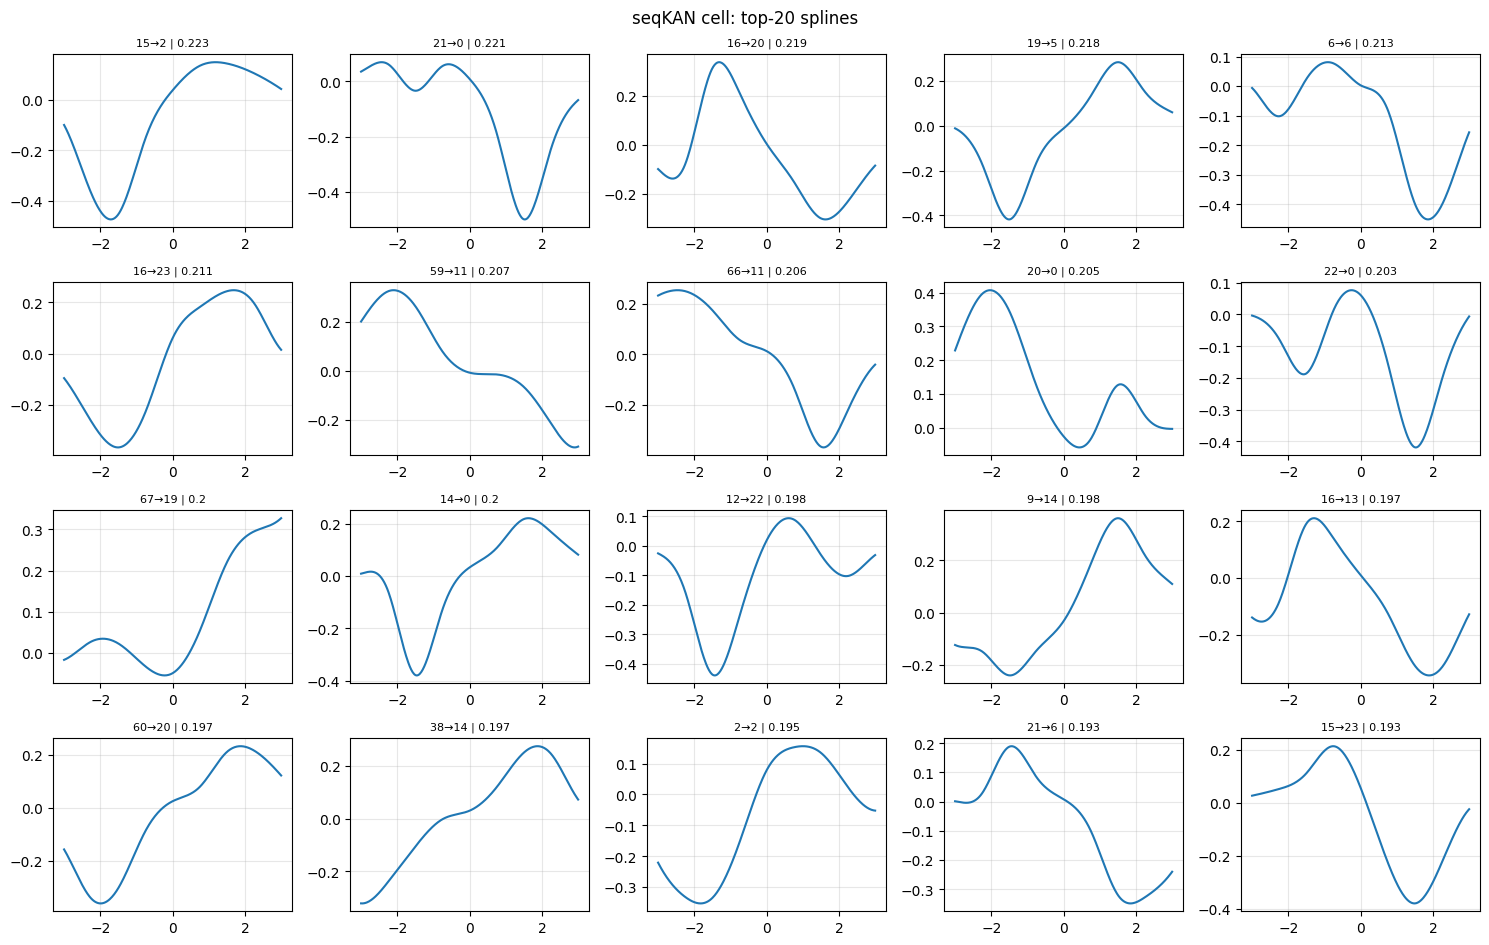

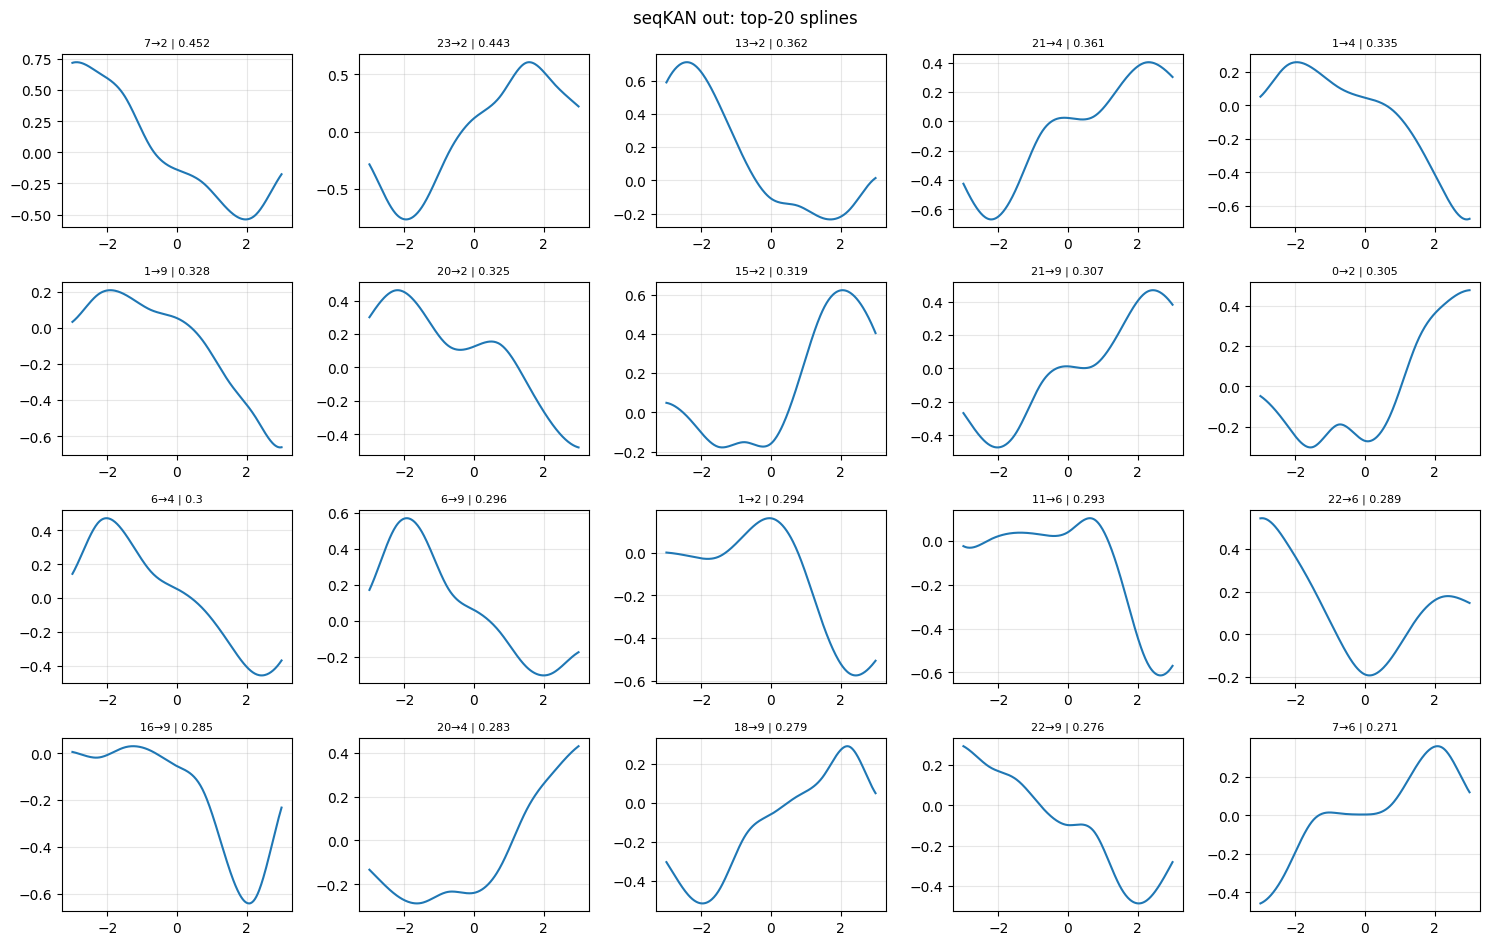

,model,TF_core_claim,TF_topk_mass_ratio,EA_method,EA_spearman_mean,EA_spearman_std,SE_seqkan_sparsity_eps,SE_gru_compress_q90,AD_pass_rate,AD_rules_n
0,seqKAN,1.0,0.152274,gradxinput,0.500684,0.000559,0.085843,NaN,0.25,4
1,GRU,0.0,NaN,gradxinput,0.500684,0.000559,NaN,0.900019,0.50,4


OK. CSVs salvos em: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results


In [11]:
# STEP-RUN-BENCHMARK-V2
import torch

if 'explainability_benchmark_v2' not in globals():
    raise ValueError('Função explainability_benchmark_v2 não encontrada. Rode a célula EXPLAINABILITY_V2 antes.')

seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
gru_model_local = globals().get('gru_model', globals().get('model_tsdf_gru', None))
if seq_model is None:
    raise ValueError('seqkan_model não encontrado. Rode CHECKPOINT_LOADER_V2.')
if gru_model_local is None:
    raise ValueError('gru_model não encontrado. Rode CHECKPOINT_LOADER_V2.')
if 'dl' not in globals():
    raise ValueError('dl não encontrado. Rode as células do DataLoader.')

if 'feature_cols' not in globals() or feature_cols is None:
    feature_cols = list(dl.df.columns[:-3])

# batch de avaliação
x_eval, ts_eval, m_eval = _make_eval_batch(
    seq_model,
    dl.df,
    feature_cols,
    timestamp_col='index',
    window_size=128,
    window_step=8,
    max_windows=256,
)

# device consistente
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seq_model = seq_model.to(device).eval()
gru_model_local = gru_model_local.to(device).eval()
x_eval = x_eval.to(device)
ts_eval = ts_eval.to(device)
m_eval = m_eval.to(device)

# executa benchmark v2
art = explainability_benchmark_v2(
    seqkan_model=seq_model,
    gru_model=gru_model_local,
    x=x_eval,
    ts=ts_eval,
    m=m_eval,
    topk=20,
    ea_method='gradxinput',
    ea_extra_methods=('ig', 'permutation_window'),
    ea_noise_pcts=(0.005, 0.01, 0.02),
    ea_n_seeds=5,
    ea_windows_per_seed=32,
    se_eps_frac=0.01,
    ad_rules=ad_rules,
    compute_seqkan_edge_time=True,
    edge_time_max_windows=64,
    make_plots=True,
)

display(art['df_main'])
display(art['df_ea_compare'].head(10))
display(art['df_perm_window_summary'].head(20))

out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'
art['df_main'].to_csv(f"{out_dir}/explainability_v2_main.csv", index=False)
art['df_top_edges_cell'].to_csv(f"{out_dir}/explainability_v2_top_edges_cell.csv", index=False)
art['df_top_edges_out'].to_csv(f"{out_dir}/explainability_v2_top_edges_out.csv", index=False)
if not art['ad_seq_details'].empty:
    art['ad_seq_details'].to_csv(f"{out_dir}/explainability_v2_ad_seqkan_details.csv", index=False)
if not art['ad_gru_details'].empty:
    art['ad_gru_details'].to_csv(f"{out_dir}/explainability_v2_ad_gru_details.csv", index=False)
if not art['df_ea_compare'].empty:
    art['df_ea_compare'].to_csv(f"{out_dir}/explainability_v2_ea_compare.csv", index=False)
if not art['df_perm_window_summary'].empty:
    art['df_perm_window_summary'].to_csv(f"{out_dir}/explainability_v2_perm_window_summary.csv", index=False)
if not art['df_seqkan_edge_time'].empty:
    art['df_seqkan_edge_time'].to_csv(f"{out_dir}/explainability_v2_seqkan_edge_time.csv", index=False)

print('OK. CSVs salvos em:', out_dir)




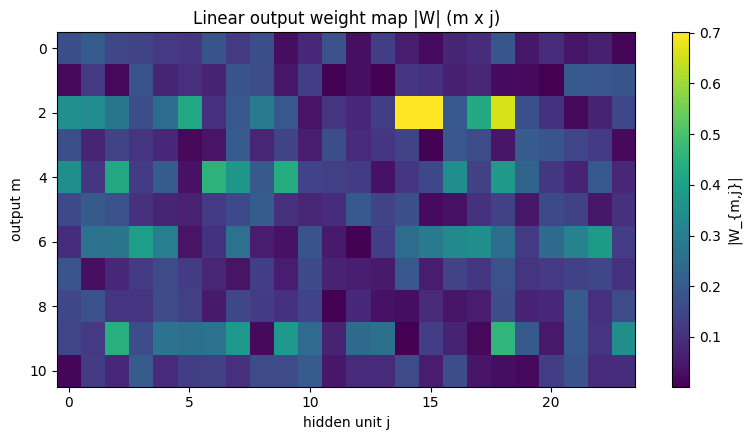

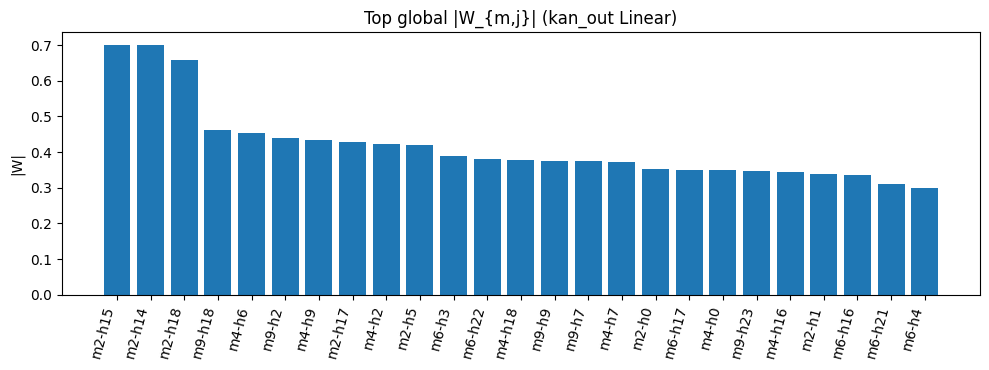

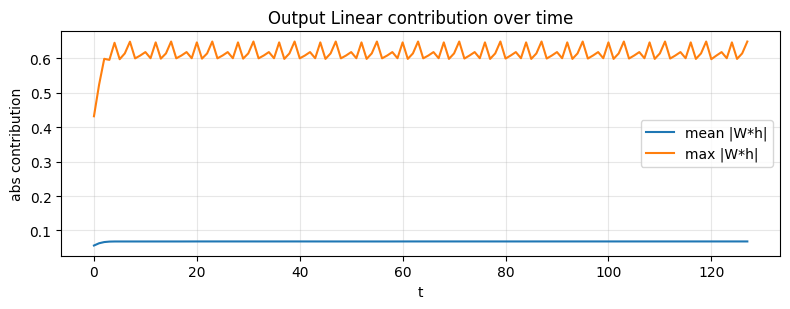

,output_m,rank,hidden_j,abs_w
0,0,1,1,0.203954
1,0,2,18,0.189156
2,0,3,6,0.184215
3,0,4,11,0.174479
4,0,5,0,0.169818
5,0,6,8,0.169074
6,0,7,2,0.149945
7,0,8,3,0.144276
8,0,9,13,0.129172
9,0,10,7,0.120123


,t,mean_abs_wh,max_abs_wh
0,0,0.056238,0.431729
1,1,0.062822,0.523508
2,2,0.066294,0.598589
3,3,0.067621,0.595526
4,4,0.067973,0.645210
5,5,0.067957,0.597480
6,6,0.068112,0.614320
7,7,0.068129,0.648389
8,8,0.068028,0.599801
9,9,0.068009,0.608170


,hidden_j,mean_abs_w,max_abs_w,n_outputs,n_cell_edges_seen,top_i_in,top_cell_scores
0,18,0.248978,0.657876,10,3,"8,4,9","0.3467,0.2936,0.2869"
1,2,0.214823,0.440350,10,2,"4,9","0.3365,0.2966"
2,14,0.211797,0.698828,9,1,8,0.3964
3,7,0.211186,0.374949,10,0,,
4,15,0.196331,0.700640,8,1,8,0.4364
5,9,0.194778,0.434835,8,2,"4,9","0.3459,0.2845"
6,0,0.179481,0.351994,10,0,,
7,16,0.175928,0.344090,9,0,,
8,21,0.174114,0.311804,9,1,6,0.2774
9,1,0.172848,0.338235,10,0,,


Saved linear-out explainability CSVs in: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results


In [24]:
# STEP-LINEAR-OUT-EXPLAIN (bloco adicional no final)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Usa modelos/artefatos já carregados no notebook
seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model/model_tsdf_seqkanseq).')

if 'x_eval' not in globals() or 'ts_eval' not in globals() or 'm_eval' not in globals():
    raise ValueError('x_eval/ts_eval/m_eval não encontrados. Rode o bloco do benchmark antes.')

out_mod = seq_model.seqKAN.kan_out
if not isinstance(out_mod, torch.nn.Linear):
    print(f"[Linear-OUT] kan_out={type(out_mod).__name__}; este bloco é para saída Linear.")
else:
    # W: (out, hidden) -> (hidden, out)
    W = out_mod.weight.detach().cpu().numpy().T
    absW = np.abs(W)
    H, M = absW.shape

    # 1) Top-k |W_{m,j}| por saída m
    topk = 20
    rows = []
    for m in range(M):
        col = absW[:, m]
        kk = min(topk, H)
        idx = np.argsort(-col)[:kk]
        for r, j in enumerate(idx, start=1):
            rows.append({'output_m': int(m), 'rank': int(r), 'hidden_j': int(j), 'abs_w': float(col[j])})
    df_top_out_linear = pd.DataFrame(rows)

    # 2) Série temporal: média de |W_{m,j} * h_{t,j}|
    x, ts, msk = x_eval, ts_eval, m_eval
    dev = next(seq_model.parameters()).device
    x, ts, msk = x.to(dev), ts.to(dev), msk.to(dev)

    seq = seq_model.seqKAN
    hs = getattr(seq, 'hidden_size', None)
    if hs is None:
        hs = getattr(seq, 'hidden_dim', None)
    if hs is None:
        raise AttributeError('seqKAN sem hidden_size/hidden_dim')
    hs = int(hs)
    B, T, _ = x.shape
    h = torch.zeros(B, hs, device=dev, dtype=x.dtype)
    mask_z = seq.mask_proj((1 - msk))

    W_t = out_mod.weight.T  # (hidden, out)
    rec = []
    with torch.no_grad():
        for t in range(T):
            x_t = x[:, t, :]
            m_t = mask_z[:, t, :] * h
            if hasattr(seq, 'kan_encoder'):
                try:
                    z_t = seq.kan_encoder(x_t)
                    h_in = torch.cat([z_t, h, m_t], dim=-1)
                except Exception:
                    h_in = torch.cat([x_t, h, m_t], dim=-1)
            else:
                h_in = torch.cat([x_t, h, m_t], dim=-1)

            h = seq.kan_cell(h_in)
            contrib = (h[:, :, None] * W_t[None, :, :]).abs()  # (B, hidden, out)

            rec.append({
                't': int(t),
                'mean_abs_wh': float(contrib.mean().item()),
                'max_abs_wh': float(contrib.max().item()),
            })

    df_out_contrib_time = pd.DataFrame(rec)

    # 3) Mapa |W| (m x j)
    plt.figure(figsize=(8, 4.5))
    plt.imshow(absW.T, aspect='auto', interpolation='nearest')
    plt.colorbar(label='|W_{m,j}|')
    plt.xlabel('hidden unit j')
    plt.ylabel('output m')
    plt.title('Linear output weight map |W| (m x j)')
    plt.tight_layout()
    plt.show()

    # Barplot top-k agregado (global)
    flat = []
    for m in range(M):
        for j in range(H):
            flat.append((m, j, absW[j, m]))
    flat.sort(key=lambda z: z[2], reverse=True)
    flat = flat[:min(25, len(flat))]

    labels = [f"m{m}-h{j}" for m, j, _ in flat]
    vals = [v for _, _, v in flat]

    plt.figure(figsize=(10, 3.8))
    plt.bar(np.arange(len(vals)), vals)
    plt.xticks(np.arange(len(vals)), labels, rotation=75, ha='right')
    plt.ylabel('|W|')
    plt.title('Top global |W_{m,j}| (kan_out Linear)')
    plt.tight_layout()
    plt.show()

    # Série temporal de contribuição
    plt.figure(figsize=(8, 3.2))
    plt.plot(df_out_contrib_time['t'], df_out_contrib_time['mean_abs_wh'], label='mean |W*h|')
    plt.plot(df_out_contrib_time['t'], df_out_contrib_time['max_abs_wh'], label='max |W*h|')
    plt.xlabel('t')
    plt.ylabel('abs contribution')
    plt.title('Output Linear contribution over time')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(df_top_out_linear.head(30))
    display(df_out_contrib_time.head(20))


    # 4) Cruzamento: hidden_j dominante (out linear) -> top i_in (cell)
    # Requer df de arestas da cell já existente no benchmark v2
    cell_csv = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/explainability_v2_top_edges_cell.csv'
    try:
        df_cell_edges = pd.read_csv(cell_csv)
        if {'i_in', 'j_out', 'score'}.issubset(df_cell_edges.columns):
            agg = (
                df_top_out_linear.groupby('hidden_j', as_index=False)
                .agg(mean_abs_w=('abs_w', 'mean'), max_abs_w=('abs_w', 'max'), n_outputs=('output_m', 'nunique'))
                .sort_values(['mean_abs_w', 'max_abs_w'], ascending=False)
            )

            rows = []
            top_hidden = agg.head(min(12, len(agg)))
            for _, r in top_hidden.iterrows():
                j = int(r['hidden_j'])
                sub = df_cell_edges[df_cell_edges['j_out'] == j].sort_values('score', ascending=False)
                top_in = sub.head(5)
                rows.append({
                    'hidden_j': j,
                    'mean_abs_w': float(r['mean_abs_w']),
                    'max_abs_w': float(r['max_abs_w']),
                    'n_outputs': int(r['n_outputs']),
                    'n_cell_edges_seen': int(sub.shape[0]),
                    'top_i_in': ','.join(str(int(x)) for x in top_in['i_in'].tolist()) if not top_in.empty else '',
                    'top_cell_scores': ','.join(f"{float(x):.4f}" for x in top_in['score'].tolist()) if not top_in.empty else '',
                })

            df_hiddenj_to_cell_topin = pd.DataFrame(rows)
            display(df_hiddenj_to_cell_topin)
            df_hiddenj_to_cell_topin.to_csv(
                f"{out_dir}/explainability_v2_hiddenj_to_cell_topin.csv", index=False
            )
        else:
            print('[Linear-OUT] explainability_v2_top_edges_cell.csv sem colunas esperadas.')
    except FileNotFoundError:
        print('[Linear-OUT] explainability_v2_top_edges_cell.csv não encontrado. Rode o benchmark v2 antes.')

    # Export opcional
    out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'
    df_top_out_linear.to_csv(f"{out_dir}/explainability_v2_top_edges_out_linear.csv", index=False)
    df_out_contrib_time.to_csv(f"{out_dir}/explainability_v2_out_linear_contrib_time.csv", index=False)
    print('Saved linear-out explainability CSVs in:', out_dir)



In [25]:
# STEP-EXPORT-FIGS-1-6 (para apresentacao_seqKAN.tex)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'
os.makedirs(out_dir, exist_ok=True)

# ----------------------------
# Fig. 1: MSE vs H (8,24,352)
# ----------------------------
H = np.array([8, 24, 352], dtype=int)
mse_seqkan = np.array([0.173, 0.159, 0.169], dtype=float)
mse_gru = np.array([0.178, 0.163, 0.146], dtype=float)

plt.figure(figsize=(6.6, 4.2))
plt.plot(H, mse_seqkan, marker='o', linewidth=2, label='TSDF_SeqKANSeq')
plt.plot(H, mse_gru, marker='s', linewidth=2, label='TSDF_GRU')
plt.xscale('log')
plt.xticks(H, [str(h) for h in H])
plt.xlabel('Hidden size H')
plt.ylabel('Test MSE')
plt.title('MSE vs H (8, 24, 352)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/fig1_mse_vs_h.png", dpi=180)
plt.close()

# -------------------------------------------------------
# Fig. 2: Diagrama feature -> spline(cell) -> hidden -> out
# -------------------------------------------------------
plt.figure(figsize=(8.0, 4.0))
ax = plt.gca()
ax.axis('off')

nodes = {
    'x': (0.08, 0.5),
    's': (0.35, 0.5),
    'h': (0.62, 0.5),
    'y': (0.88, 0.5),
}
labels = {
    'x': 'Features x_t\n(C=11)',
    's': 'KAN cell splines\nedge-wise f_ij',
    'h': 'Hidden h_t\n(H)',
    'y': 'Output x_hat_t\n(Linear out)',
}
for k,(xx,yy) in nodes.items():
    ax.text(xx, yy, labels[k], ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#f4f6f8', edgecolor='#2f3b52'))

for a,b in [('x','s'),('s','h'),('h','y')]:
    x1,y1 = nodes[a]
    x2,y2 = nodes[b]
    ax.annotate('', xy=(x2-0.08,y2), xytext=(x1+0.08,y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='#2f3b52'))

ax.text(0.50, 0.18, 'Interpretação: top edges na cell + |W| e |W*h| na saída linear',
        ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{out_dir}/fig2_feature_spline_hidden_output.png", dpi=180)
plt.close()

# ------------------------------------------
# Fig. 3: Top-20 splines na KAN cell
# ------------------------------------------
p_cell = f"{out_dir}/explainability_v2_top_edges_cell.csv"
if os.path.exists(p_cell):
    df_cell = pd.read_csv(p_cell).sort_values('score', ascending=False).head(20).copy()
    df_cell['edge'] = df_cell.apply(lambda r: f"{int(r['i_in'])}->{int(r['j_out'])}", axis=1)

    plt.figure(figsize=(10.5, 4.2))
    plt.bar(np.arange(len(df_cell)), df_cell['score'].to_numpy())
    plt.xticks(np.arange(len(df_cell)), df_cell['edge'].tolist(), rotation=75, ha='right')
    plt.ylabel('edge score')
    plt.title('Top-20 edges/splines na KAN cell')
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/fig3_top20_splines_cell.png", dpi=180)
    plt.close()

# ------------------------------------------
# Fig. 4: Edge attribution temporal
# ------------------------------------------
p_edge_time = f"{out_dir}/explainability_v2_seqkan_edge_time.csv"
if os.path.exists(p_edge_time):
    dft = pd.read_csv(p_edge_time)
    need = {'t','cell_edge_contrib_mean','out_edge_contrib_mean'}
    if need.issubset(dft.columns):
        plt.figure(figsize=(8.2, 3.6))
        plt.plot(dft['t'], dft['cell_edge_contrib_mean'], label='cell mean')
        plt.plot(dft['t'], dft['out_edge_contrib_mean'], label='out mean')
        plt.xlabel('t')
        plt.ylabel('mean abs edge contrib')
        plt.title('Edge attribution temporal (cell vs out)')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{out_dir}/fig4_edge_attribution_time.png", dpi=180)
        plt.close()

# ------------------------------------------
# Fig. 5: Heatmap |W| (m x j)
# ------------------------------------------
absW = None
seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is not None:
    try:
        out_mod = seq_model.seqKAN.kan_out
        import torch
        if isinstance(out_mod, torch.nn.Linear):
            # (out, hidden) -> (m x j)
            absW = np.abs(out_mod.weight.detach().cpu().numpy())
    except Exception:
        absW = None

if absW is None:
    p_out = f"{out_dir}/explainability_v2_top_edges_out_linear.csv"
    if os.path.exists(p_out):
        dfo = pd.read_csv(p_out)
        if {'output_m','hidden_j','abs_w'}.issubset(dfo.columns):
            mmax = int(dfo['output_m'].max()) + 1
            jmax = int(dfo['hidden_j'].max()) + 1
            M = np.zeros((mmax, jmax), dtype=float)
            for _,r in dfo.iterrows():
                M[int(r['output_m']), int(r['hidden_j'])] = float(r['abs_w'])
            absW = M

if absW is not None:
    plt.figure(figsize=(8.4, 4.2))
    plt.imshow(absW, aspect='auto', interpolation='nearest')
    plt.colorbar(label='|W_{m,j}|')
    plt.xlabel('hidden j')
    plt.ylabel('output m')
    plt.title('Mapa |W| (output m x hidden j)')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/fig5_absW_heatmap.png", dpi=180)
    plt.close()

# ------------------------------------------
# Fig. 6: mean/max |W*h| ao longo do tempo
# ------------------------------------------
p_wh = f"{out_dir}/explainability_v2_out_linear_contrib_time.csv"
if os.path.exists(p_wh):
    dfwh = pd.read_csv(p_wh)
    need = {'t','mean_abs_wh','max_abs_wh'}
    if need.issubset(dfwh.columns):
        plt.figure(figsize=(8.2, 3.6))
        plt.plot(dfwh['t'], dfwh['mean_abs_wh'], label='mean |W*h|')
        plt.plot(dfwh['t'], dfwh['max_abs_wh'], label='max |W*h|')
        plt.xlabel('t')
        plt.ylabel('abs contribution')
        plt.title('mean/max |W*h| ao longo do tempo')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{out_dir}/fig6_mean_max_absWh_time.png", dpi=180)
        plt.close()

print('Figuras exportadas (se dados disponíveis):')
for fn in [
    'fig1_mse_vs_h.png',
    'fig2_feature_spline_hidden_output.png',
    'fig3_top20_splines_cell.png',
    'fig4_edge_attribution_time.png',
    'fig5_absW_heatmap.png',
    'fig6_mean_max_absWh_time.png',
]:
    fp = f"{out_dir}/{fn}"
    print(f"- {fn}:", 'OK' if os.path.exists(fp) else 'MISSING')



Figuras exportadas (se dados disponíveis):
- fig1_mse_vs_h.png: OK
- fig2_feature_spline_hidden_output.png: OK
- fig3_top20_splines_cell.png: OK
- fig4_edge_attribution_time.png: OK
- fig5_absW_heatmap.png: OK
- fig6_mean_max_absWh_time.png: OK


In [ ]:
# STEP-PLOT-FEATURE-GRID-AND-IMPACT (SeqKAN cell spline + impacto na saída)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

# -------------------------------
# Configuração rápida
# -------------------------------
# Se None, escolhe automaticamente uma feature forte no top_edges_cell
FEATURE_IDX = None       # ex.: 8
OUTPUT_IDX = None        # ex.: 2 (se None, escolhe pelo maior |W_{m,j}| do hidden_j dominante)
N_GRID = 300

out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'

seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model/model_tsdf_seqkanseq).')

seq = seq_model.seqKAN
if not hasattr(seq, 'kan_cell') or not hasattr(seq.kan_cell, 'act_fun'):
    raise ValueError('kan_cell.act_fun não disponível neste modelo.')

layer = seq.kan_cell.act_fun[0]

# -------------------------------
# 1) Escolha de feature e hidden j
# -------------------------------
df_cell = pd.read_csv(f"{out_dir}/explainability_v2_top_edges_cell.csv")
if FEATURE_IDX is None:
    feature_idx = int(df_cell.iloc[0]['i_in'])
else:
    feature_idx = int(FEATURE_IDX)

sub_feat = df_cell[df_cell['i_in'] == feature_idx].sort_values('score', ascending=False)
if sub_feat.empty:
    # fallback: top global
    j_out = int(df_cell.iloc[0]['j_out'])
    feature_idx = int(df_cell.iloc[0]['i_in'])
else:
    j_out = int(sub_feat.iloc[0]['j_out'])

# -------------------------------
# 2) Escolha do output m (saída linear)
# -------------------------------
out_mod = seq.kan_out
if not isinstance(out_mod, torch.nn.Linear):
    raise ValueError(f'Este bloco assume kan_out Linear. Recebido: {type(out_mod).__name__}')

W = out_mod.weight.detach().cpu().numpy()  # (out_m, hidden_j)
if OUTPUT_IDX is None:
    output_m = int(np.argmax(np.abs(W[:, j_out])))
else:
    output_m = int(OUTPUT_IDX)

w_mj = float(W[output_m, j_out])

# -------------------------------
# 3) Curva da spline f_{i->j}(x) + nós do grid
# -------------------------------
k = int(layer.k)
grid_row = layer.grid[feature_idx].detach().cpu().numpy()
# região válida para avaliação das splines
x_min, x_max = float(grid_row[k]), float(grid_row[-k-1])
x = np.linspace(x_min, x_max, int(N_GRID))

x_t = torch.tensor(x, dtype=layer.grid.dtype, device=layer.grid.device).view(-1, 1)
grid_t = layer.grid[feature_idx:feature_idx+1]
coef_t = layer.coef[feature_idx:feature_idx+1, j_out:j_out+1]

with torch.no_grad():
    y = coef2curve(x_t, grid_t, coef_t, layer.k)[:, 0, 0]
    if hasattr(layer, 'mask') and layer.mask is not None:
        y = y * layer.mask[feature_idx, j_out]
y = y.detach().cpu().numpy()

# contribuição no caminho feature->j->output_m (aprox. linear no último estágio)
path_contrib = w_mj * y

# -------------------------------
# 4) Curva empírica de impacto no output (PD simples)
# -------------------------------
if 'x_eval' in globals() and 'ts_eval' in globals() and 'm_eval' in globals():
    x_eval_pd = x_eval[:64].clone()
    ts_eval_pd = ts_eval[:64].clone()
    m_eval_pd = m_eval[:64].clone()

    dev = next(seq_model.parameters()).device
    x_eval_pd = x_eval_pd.to(dev)
    ts_eval_pd = ts_eval_pd.to(dev)
    m_eval_pd = m_eval_pd.to(dev)

    ys = []
    seq_model.eval()
    for v in x:
        xv = x_eval_pd.clone()
        xv[:, :, feature_idx] = float(v)
        with torch.no_grad():
            out = seq_model.forward(xv, timestamps=ts_eval_pd, return_x_hat=True, mask=m_eval_pd, test=True)
            # x_hat na última posição temporal
            yhat = out[3][:, -1, output_m].mean().item()
        ys.append(yhat)
    pd_out = np.array(ys, dtype=float)
else:
    pd_out = None

# -------------------------------
# 5) Plot
# -------------------------------
fig, axes = plt.subplots(1, 2 if pd_out is not None else 1, figsize=(12, 4.2))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

ax0 = axes[0]
ax0.plot(x, y, label=f'spline f_{{{feature_idx}->{j_out}}}(x)')
for gx in grid_row:
    ax0.axvline(float(gx), color='gray', alpha=0.15, linewidth=0.8)
ax0.plot(x, path_contrib, '--', label=f'path contrib = W[{output_m},{j_out}] * f(x)')
ax0.set_title('SeqKAN cell spline + grid + contribuição no output')
ax0.set_xlabel(f'feature x[{feature_idx}]')
ax0.set_ylabel('valor')
ax0.grid(alpha=0.25)
ax0.legend(fontsize=8)

if pd_out is not None and len(axes) > 1:
    ax1 = axes[1]
    ax1.plot(x, pd_out, color='tab:green')
    ax1.set_title(f'Impacto empírico em output[{output_m}] (PD)')
    ax1.set_xlabel(f'feature x[{feature_idx}]')
    ax1.set_ylabel('mean y_hat (last step)')
    ax1.grid(alpha=0.25)

fig.suptitle(
    f'Feature {feature_idx} -> hidden j={j_out} -> output m={output_m} | W_mj={w_mj:.4f}',
    fontsize=11,
)
fig.tight_layout()
plt.show()

# Salva figura para usar no slide se quiser
fig_path = f"{out_dir}/fig_feature{feature_idx}_grid_spline_impact_m{output_m}_j{j_out}.png"
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
print('Figura salva em:', fig_path)
print(f'feature_idx={feature_idx}, hidden_j={j_out}, output_m={output_m}, W_mj={w_mj:.4f}')



In [ ]:
# STEP-PLOT-TOP3-FEATURES-GRID-AND-IMPACT (painel consolidado)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

TOPN = 3
N_GRID = 240
out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'

seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model/model_tsdf_seqkanseq).')

seq = seq_model.seqKAN
layer = seq.kan_cell.act_fun[0]
out_mod = seq.kan_out
if not isinstance(out_mod, torch.nn.Linear):
    raise ValueError(f'Este bloco assume kan_out Linear. Recebido: {type(out_mod).__name__}')

# escolhe TOPN features pelos maiores scores no top_edges_cell
p_cell = f"{out_dir}/explainability_v2_top_edges_cell.csv"
df_cell = pd.read_csv(p_cell).sort_values('score', ascending=False)
feat_order = []
for _, r in df_cell.iterrows():
    i = int(r['i_in'])
    if i not in feat_order:
        feat_order.append(i)
    if len(feat_order) >= TOPN:
        break
if len(feat_order) == 0:
    raise ValueError('Não encontrei features em explainability_v2_top_edges_cell.csv')

W = out_mod.weight.detach().cpu().numpy()  # (out_m, hidden_j)

# prepara batch para PD
has_eval = all(k in globals() for k in ['x_eval', 'ts_eval', 'm_eval'])
if has_eval:
    x_eval_pd = x_eval[:64].clone()
    ts_eval_pd = ts_eval[:64].clone()
    m_eval_pd = m_eval[:64].clone()
    dev = next(seq_model.parameters()).device
    x_eval_pd = x_eval_pd.to(dev)
    ts_eval_pd = ts_eval_pd.to(dev)
    m_eval_pd = m_eval_pd.to(dev)

fig, axes = plt.subplots(len(feat_order), 2 if has_eval else 1, figsize=(12, 3.6 * len(feat_order)))
if len(feat_order) == 1:
    axes = np.array([axes])
if axes.ndim == 1:
    axes = axes.reshape(len(feat_order), 1)

summary_rows = []

for row_idx, feature_idx in enumerate(feat_order):
    sub_feat = df_cell[df_cell['i_in'] == feature_idx].sort_values('score', ascending=False)
    j_out = int(sub_feat.iloc[0]['j_out'])
    output_m = int(np.argmax(np.abs(W[:, j_out])))
    w_mj = float(W[output_m, j_out])

    k = int(layer.k)
    grid_row = layer.grid[feature_idx].detach().cpu().numpy()
    x_min, x_max = float(grid_row[k]), float(grid_row[-k-1])
    x = np.linspace(x_min, x_max, int(N_GRID))

    x_t = torch.tensor(x, dtype=layer.grid.dtype, device=layer.grid.device).view(-1, 1)
    grid_t = layer.grid[feature_idx:feature_idx+1]
    coef_t = layer.coef[feature_idx:feature_idx+1, j_out:j_out+1]

    with torch.no_grad():
        y = coef2curve(x_t, grid_t, coef_t, layer.k)[:, 0, 0]
        if hasattr(layer, 'mask') and layer.mask is not None:
            y = y * layer.mask[feature_idx, j_out]
    y = y.detach().cpu().numpy()
    path_contrib = w_mj * y

    ax0 = axes[row_idx, 0]
    ax0.plot(x, y, label=f'f_{{{feature_idx}->{j_out}}}(x)')
    for gx in grid_row:
        ax0.axvline(float(gx), color='gray', alpha=0.12, linewidth=0.8)
    ax0.plot(x, path_contrib, '--', label=f'W[{output_m},{j_out}] * f(x)')
    ax0.set_title(f'Feature {feature_idx} -> hidden j={j_out} (output m={output_m})')
    ax0.set_xlabel(f'x[{feature_idx}]')
    ax0.set_ylabel('valor')
    ax0.grid(alpha=0.25)
    ax0.legend(fontsize=8)

    pd_out = None
    if has_eval:
        ys = []
        seq_model.eval()
        for v in x:
            xv = x_eval_pd.clone()
            xv[:, :, feature_idx] = float(v)
            with torch.no_grad():
                out = seq_model.forward(xv, timestamps=ts_eval_pd, return_x_hat=True, mask=m_eval_pd, test=True)
                yhat = out[3][:, -1, output_m].mean().item()
            ys.append(yhat)
        pd_out = np.array(ys, dtype=float)

        ax1 = axes[row_idx, 1]
        ax1.plot(x, pd_out, color='tab:green')
        ax1.set_title(f'PD em output[{output_m}]')
        ax1.set_xlabel(f'x[{feature_idx}]')
        ax1.set_ylabel('mean y_hat (last)')
        ax1.grid(alpha=0.25)

    summary_rows.append({
        'feature_idx': feature_idx,
        'hidden_j': j_out,
        'output_m': output_m,
        'w_mj': w_mj,
        'cell_score': float(sub_feat.iloc[0]['score']),
    })

fig.suptitle('Top-3 features: grid da spline + contribuição no output', fontsize=12)
fig.tight_layout()

png_path = f"{out_dir}/fig_top3_features_grid_spline_impact.png"
fig.savefig(png_path, dpi=180, bbox_inches='tight')
plt.show()

summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(f"{out_dir}/explainability_v2_top3_feature_path_summary.csv", index=False)
print('Figura salva em:', png_path)
print('Resumo salvo em:', f"{out_dir}/explainability_v2_top3_feature_path_summary.csv")



In [ ]:
# STEP-KAN-THIRD-ORDER-FUNCTION (f_ij de 3a ordem, k=3)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

# Escolha da aresta na KAN cell
I_IN = 8
J_OUT = 15
N_GRID = 400
SAVE_CSV = True

out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'

seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model/model_tsdf_seqkanseq).')

layer = seq_model.seqKAN.kan_cell.act_fun[0]
k = int(layer.k)

if k != 3:
    print(f'[WARN] Esta camada está com k={k}, não k=3.')

# intervalo válido do spline para a feature I_IN
grid_row = layer.grid[I_IN].detach().cpu().numpy()
x_min, x_max = float(grid_row[k]), float(grid_row[-k-1])
x = np.linspace(x_min, x_max, int(N_GRID))

x_t = torch.tensor(x, dtype=layer.grid.dtype, device=layer.grid.device).view(-1, 1)
grid_t = layer.grid[I_IN:I_IN+1]
coef_t = layer.coef[I_IN:I_IN+1, J_OUT:J_OUT+1]

with torch.no_grad():
    y = coef2curve(x_t, grid_t, coef_t, layer.k)[:, 0, 0]
    if hasattr(layer, 'mask') and layer.mask is not None:
        y = y * layer.mask[I_IN, J_OUT]
y = y.detach().cpu().numpy()

plt.figure(figsize=(8.5, 4.0))
plt.plot(x, y, label=f'f_{{{I_IN}->{J_OUT}}}(x), k={k} = \sum_r c_r B_{{r,3}}(x)')
for gx in grid_row:
    plt.axvline(float(gx), color='gray', alpha=0.15, linewidth=0.8)
plt.title('Função KAN de 3a ordem: $f_{ij}(x)=\sum_r c_r B_{r,3}(x)$')
plt.xlabel(f'x[{I_IN}]')
plt.ylabel('f_ij(x)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

if SAVE_CSV:
    df_fun = pd.DataFrame({'x': x, 'f_ij': y})
    csv_path = f"{out_dir}/kan_function_i{I_IN}_j{J_OUT}_k{k}.csv"
    df_fun.to_csv(csv_path, index=False)
    print('CSV salvo em:', csv_path)


print('Forma analítica: f_ij(x) = sum_r c_r B_{r,3}(x) (spline cúbica)')
